<div style="border:solid Chocolate 2px; padding: 40px">

<b>Илья, привет!</b>

Меня зовут Евгений Головин, я буду ревьюером твоего проекта. Если ты не против, то предлагаю построить наше общение на "ты" ;) Если удобнее на "вы", то нет проблем, только скажи об этом. 

В ходе работы я оставил тебе комментарии <font color='green'>зеленого</font>, <font color='gold'>желтого</font> и <font color='red'>красного</font> цветов. Сейчас объясню, что они значат:

<br/>

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Решение на этом шаге является полностью правильным.
</div>

<br/>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> Решение на этом шаге станет еще лучше, если внести небольшие коррективы.
</div>


<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку🤔:</b>
 Решение на этом шаге требует существенной переработки и внесения правок. Напоминаю, что проект не может быть принят с первого раза, если ревью содержит комментарии, рекомендующие доработать шаги.
</div>
    
Увидев мой комментарий, не удаляй его, он будет очень полезен в случае повторной проверки работы :)
    
<div class="alert alert-info">
<b>А свой помечай вот так, чтобы я его не потерял ;)</b> 
</div>
    
На мои комменатрии можно и нужно реагировать, только делать это стоит так, чтобы твои и мои комменты не смешались: выделяй свои цветами, сильно отличающимися от моих.
    
Увидев у тебя неточность, в первый раз я лишь укажу на ее наличие и дам тебе возможность самому найти и исправить ее. На реальной работе твой руководитель будет поступать также, и я пытаюсь подготовить тебя именно к работе аналитиком. Но если ты пока не справишься с такой задачей - при следующей проверке я дам более точную подсказку!
</div>

<div class="alert alert-info">
<b>Евгений, привет! Постараюсь максимально учесть твои замечания.</b> 
</div>

# Проект: семантический поиск товаров по текстовому запросу

**Автор:** Илья Иванов  
**Дата:** 25.09.2026

**Ваша роль.** Вы специалист по Data Science. Компания развивает онлайн-каталог товаров, и сейчас руководству кажется, что классический поиск по ключевым словам плохо справляется с реальными запросами. Пользователи пишут названия с ошибками, кириллицей, используют просторечные слова, ищут товары по назначению, а не по функциональности («удобные кроссовки для бега» вместо «мужские спортивные кроссовки с амортизацией»). Команда хочет проверить, поможет ли векторный поиск улучшить качество поисковой системы.

**Задача.** Вам нужно построить MVP системы семантического поиска, сравнить его с лексической baseline-моделью на подготовленной разметке и дать бизнесу обоснованную рекомендацию о том, где новое решение помогает, где ошибается и стоит ли его вообще внедрять.

## Данные

| Файл | Что это | Когда нужен |
|---|---|---|
| wb_products_raw_sample.parquet | Исходный каталог, ~200 тысяч строк, все категории. <br> Вам нужно самостоятельно отобрать рабочее подмножество этих данных | Недели 1–2 |
| wb_products_dedup.parquet | Пул асессоров: множество товаров, по которому делалась разметка | Неделя 2, раздел 4 |
| queries_synthetic_train.parquet | Разметка релевантности, train | Недели 2–3 |
| queries_synthetic_test.parquet | Разметка релевантности, test | **один прогон** в конце недели 3 |

Файлы с разметкой содержат четыре столбца: `query_id`, `query_text`, `item_id`, `relevance`. Шкала в `relevance` от `0` до `3`, где `0` — товар нерелевантен, а `3` — максимально релевантен. Связь с каталогом: `item_id` ↔ `imt_id`.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 150)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
RAW_PRODUCTS_PATH = DATA_DIR / "wb_products_raw_sample.parquet"
ASSESSED_POOL_PATH = DATA_DIR / "wb_products_dedup.parquet"
TRAIN_QUERIES_PATH = DATA_DIR / "queries_synthetic_train.parquet"
TEST_QUERIES_PATH = DATA_DIR / "queries_synthetic_test.parquet"

---

## Неделя 1 — знакомство с данными и EDA

**Цель** — понять, с какими данными работаете, чтобы принять обоснованные решения:

- выбрать категории, с которыми будете работать;
- определить, как будете очищать описания от всего лишнего;
- решить, из каких полей собирать текст товара.

**Главный критерий успеха:** любое ваше решение по данным вы можете подкрепить ссылкой на конкретные результаты анализа.

### 1. Загрузка данных

Загрузите каталог и обе разметки. Изучите их структуру: проанализируйте колонки и типы данных в них, определите, что описывает одна строка.

**Подсказка.** `imt_id` — карточка товара, `nm_id` — конкретный артикул этого товара, то есть его разновидность, отличающаяся цветом, размером или чем-то ещё. Определите, что из этого должен возвращать поиск, — от этого зависит, на каком уровне вы будете строить индекс.

In [2]:
df_raw = pd.read_parquet(RAW_PRODUCTS_PATH)
queries_train = pd.read_parquet(TRAIN_QUERIES_PATH)
queries_test = pd.read_parquet(TEST_QUERIES_PATH)

for name, df in [("каталог", df_raw), ("train", queries_train), ("test", queries_test)]:
    print(f"--- {name}: {df.shape}")
    print(df.dtypes.to_string(), end="\n\n")
df_raw.head()

--- каталог: (200000, 9)
imt_id             int64
nm_id              int64
imt_name             str
subj_name            str
subj_root_name       str
nm_colors_names      str
vendor_code          str
description          str
brand_name           str

--- train: (11453, 4)
query_id        str
query_text      str
item_id       int64
relevance     int64

--- test: (4866, 4)
query_id        str
query_text      str
item_id       int64
relevance     int64



,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
0,100000,118982,Сумка,Сумки,Аксессуары,бежевый,82992/beige,,Pola
1,1000000,1206857,Шапка,Шапки,Головные уборы,белый,Лаки/белый,,Ваша Шляпка
2,1000000,1206860,Шапка,Шапки,Головные уборы,черный,Лаки/черный,,Ваша Шляпка
3,10000000,13349975,Очки TRUESPIN Fold,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.564/Black/Black,,True Spin
4,10000001,13349981,Очки TRUESPIN Candor,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.567/Black,,True Spin


**Проверьте связность данных:** все ли `item_id` из разметки есть в каталоге, нет ли пересечения `query_id` между `train` и `test`.

In [3]:
catalog_ids = set(df_raw["imt_id"])
for name, q in [("train", queries_train), ("test", queries_test)]:
    print(
        f"{name}: пар {len(q)}, запросов {q['query_id'].nunique()}, "
        f"item_id нет в каталоге: {(~q['item_id'].isin(catalog_ids)).sum()}"
    )

for col in ("query_id", "query_text"):
    common = set(queries_train[col]) & set(queries_test[col])
    print(f"Пересечение train/test по {col}: {len(common)}")

train: пар 11453, запросов 700, item_id нет в каталоге: 0
test: пар 4866, запросов 300, item_id нет в каталоге: 0
Пересечение train/test по query_id: 0
Пересечение train/test по query_text: 0


### Вывод по загрузке данных

- **Каталог:** 200 000 строк, 9 колонок. Одна строка — артикул (`nm_id`), несколько строк могут относиться к одной карточке `imt_id`: например, шапка `imt_id=1000000` представлена белым и чёрным артикулами. Поиск должен возвращать карточки, поэтому индексируем на уровне `imt_id`, а дубликаты артикулов нужно будет устранить.
- **Разметка:** train — 11 453 пары и 700 запросов (≈16 оценённых товаров на запрос), test — 4 866 пар и 300 запросов (≈16 на запрос). Структура обеих выборок одинаковая: `query_id`, `query_text`, `item_id`, `relevance`.
- **Связность:** все `item_id` из train и test есть в каталоге (`imt_id`), подсоединять разметку можно без потерь.
- **Утечка:** пересечений между train и test нет ни по `query_id`, ни по `query_text`, то есть разбиение по запросам корректно.
- **Первое наблюдение по качеству:** в `description` уже в первых строках встречаются пустые строки, а не `NaN`. Поэтому пропуски нужно считать с учётом пустых значений.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Отличный старт. Пути вынесены в константы через <code>pathlib</code>, сид зафиксирован, структура всех трёх файлов выведена одним циклом. Проверка связности сделана полностью: и покрытие <code>item_id</code> каталогом, и пересечение train/test. Особенно понравилось, что пересечение проверено не только по <code>query_id</code>, но и по <code>query_text</code> - одинаковый запрос под разными id был бы скрытой утечкой, и об этом мало кто думает. Уровень индексации (<code>imt_id</code>) выбран сразу и с правильным аргументом.
</div>

### 2. EDA

In [4]:
n_imt, n_nm = df_raw["imt_id"].nunique(), df_raw["nm_id"].nunique()
print(f"Уникальных imt_id: {n_imt}, nm_id: {n_nm}")
print(f"Полных дубликатов строк: {df_raw.duplicated().sum()}")
print(f"Дубликатов nm_id: {df_raw['nm_id'].duplicated().sum()}")
print("Артикулов на карточку:")
df_raw.groupby("imt_id").size().describe().round(2)

Уникальных imt_id: 174427, nm_id: 199957
Полных дубликатов строк: 0
Дубликатов nm_id: 43
Артикулов на карточку:


count    174427.00
mean          1.15
std           0.88
min           1.00
25%           1.00
50%           1.00
75%           1.00
max          30.00
dtype: float64

**Вывод: структура каталога**

- 200 000 строк описывают 174 427 карточек (`imt_id`) и 199 957 артикулов (`nm_id`).
- Карточки в основном «одноартикульные»: медиана — 1 артикул, среднее — 1.15, но встречаются карточки с числом артикулов до 30. Если индексировать артикулы, такие товары будут многократно конкурировать сами с собой в выдаче. Поэтому индексируем на уровне `imt_id` и оставляем одну строку на карточку.
- Полных дубликатов строк нет. 43 `nm_id` повторяются с различиями в полях. Это 0.02% данных, и вопрос снимается дедупликацией по `imt_id`.

In [5]:
text_cols = [
    "imt_name",
    "description",
    "nm_colors_names",
    "brand_name",
    "subj_name",
    "subj_root_name",
]
missing = pd.DataFrame(
    {
        "nan": df_raw[text_cols].isna().mean(),
        "empty": df_raw[text_cols].apply(lambda s: s.str.strip().eq("").mean()),
    }
)
missing["total"] = missing.sum(axis=1)
(missing * 100).round(2).sort_values("total", ascending=False)

,nan,empty,total
description,0.0,28.75,28.75
nm_colors_names,0.0,17.11,17.11
imt_name,0.0,0.35,0.35
brand_name,0.0,0.10,0.10
subj_name,0.0,0.00,0.00
subj_root_name,0.0,0.00,0.00


**Вывод: пропуски**

- Явных `NaN` нет ни в одной колонке: все пропуски закодированы пустыми строками, поэтому `isna()` показал бы обманчиво чистую картину.
- `description` пуст у **28.75%** строк. Это системное свойство данных, а не случайность. Такие товары не удаляем: их текст для эмбеддинга соберём из названия и категории, а флаг `has_description` понадобится позже для проверки, не проседает ли на них качество поиска.
- `nm_colors_names` пуст у 17.11% строк. Цвет — вспомогательный атрибут, проверим, нужен ли он в тексте.
- `imt_name` пуст у 0.35%, `brand_name` — у 0.10%. Категории заполнены полностью.
- При дедупликации будем оставлять строку с самым длинным описанием, поэтому на уровне карточек доля товаров без описания может снизиться. Пересчитаем её на подготовленном каталоге.

In [6]:
cards = df_raw.drop_duplicates("imt_id").set_index("imt_id")
pool_ids = pd.read_parquet(ASSESSED_POOL_PATH, columns=["imt_id"])["imt_id"]
labeled = pd.concat([queries_train, queries_test])
relevant_ids = labeled.loc[labeled["relevance"] >= 2, "item_id"]


def root_share(ids=None):
    """Доля карточек по корневым категориям (в %)."""
    s = cards["subj_root_name"]
    s = s if ids is None else s[s.index.isin(ids)]
    return s.value_counts(normalize=True) * 100


roots = (
    pd.DataFrame(
        {
            "catalog": root_share(),
            "pool": root_share(pool_ids),
            "relevant": root_share(relevant_ids),
        }
    )
    .fillna(0)
    .sort_values("relevant", ascending=False)
)
roots["relevant_cum"] = roots["relevant"].cumsum()
print(f"Корневых категорий: {len(roots)}")
roots.head(15).round(2)

Корневых категорий: 65


,catalog,pool,relevant,relevant_cum
subj_root_name,,,,
Одежда,21.19,79.44,73.35,73.35
Обувь,6.61,20.56,26.65,100.00
,0.00,0.00,0.00,100.00
Автомобильные товары,2.21,0.00,0.00,100.00
Автоэлектроника,0.05,0.00,0.00,100.00
Аксессуары для малышей,0.07,0.00,0.00,100.00
Аксессуары для обуви,0.15,0.00,0.00,100.00
Аксессуары,7.58,0.00,0.00,100.00
Аксессуары для волос,0.99,0.00,0.00,100.00


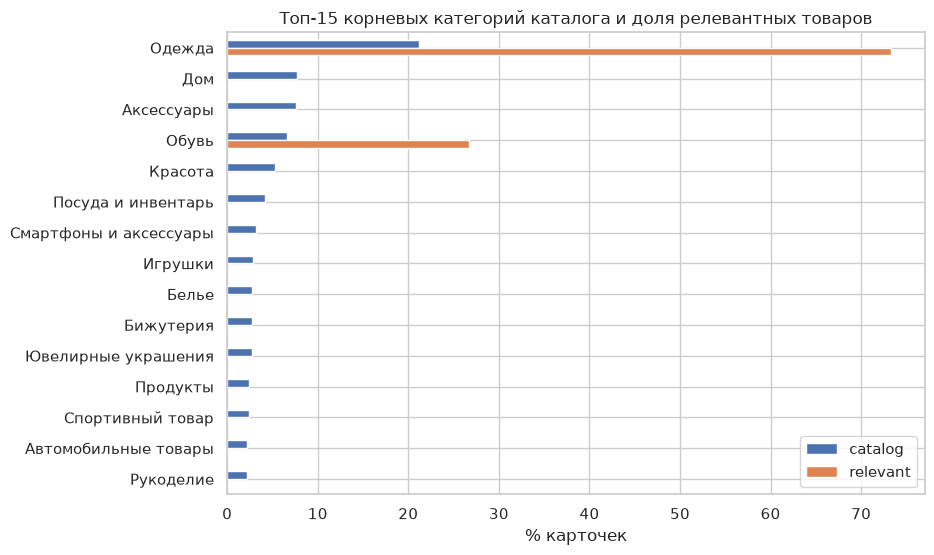

In [7]:
top = roots.sort_values("catalog", ascending=False).head(15)
ax = top[["catalog", "relevant"]].plot.barh(figsize=(9, 6))
ax.invert_yaxis()
ax.set(
    xlabel="% карточек",
    ylabel="",
    title="Топ-15 корневых категорий каталога и доля релевантных товаров",
)
plt.show()

In [8]:
subj = cards["subj_name"].value_counts()
print(f"Уникальных subj_name: {len(subj)}, с 1–2 карточками: {(subj <= 2).sum()}")
print("\nСамые частые:", subj.head(10).to_dict())
print("\nСамые редкие:", subj.tail(10).to_dict())

Уникальных subj_name: 3234, с 1–2 карточками: 820

Самые частые: {'Платья': 6113, 'Футболки': 4524, 'Сумки': 4050, 'Брюки': 2858, 'Постельное белье': 2342, 'Чехлы для телефонов': 2189, 'Автомобильные ароматизаторы': 2157, 'Блузки': 2076, 'Костюмы': 2025, 'Туфли': 2013}

Самые редкие: {'Вилки поварские': 1, 'Сумки для сбора урожая': 1, 'Межпальцевые перегородки': 1, 'Кронштейны для аудиотехники': 1, 'DVD-плееры': 1, 'Ведерки детские': 1, 'Карнавальные парики': 1, 'Средства профилактики': 1, 'Гладильные системы': 1, 'Стиральные машины активаторного типа': 1}


**Вывод: категории**

- В каталоге 65 корневых категорий. Самые крупные — «Одежда» (21.2% карточек), «Аксессуары» (7.6%) и «Обувь» (6.6%). Встречается и пустое значение `subj_root_name` (доли процента).
- **Весь пул асессоров и все релевантные товары разметки (relevance ≥ 2) лежат только в двух корнях: «Одежда» (73% релевантных) и «Обувь» (27%).** Остальные 63 корня в разметке не представлены.
- **Решение: MVP строим на категориях «Одежда» и «Обувь».** Их товары покрывают разметку полностью, у них понятные атрибуты (назначение, сезон, пол, материал), а ошибки поиска в таком домене легко интерпретировать. Если бы в индекс попали остальные категории, выросли бы объём вычислений и шум в выдаче, а метрики не получили бы ни одного размеченного товара.
- Предметных категорий `subj_name` — 3 234, из них 820 содержат 1–2 карточки. Хвост в основном состоит из категорий вне выбранного домена (поварские вилки, DVD-плееры). В редких категориях внутри домена качество поиска будет менее стабильным, это учтём при анализе ошибок.
- Самые частые предметные категории внутри домена — «Платья», «Футболки», «Брюки», «Блузки», «Костюмы», «Туфли».

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Главная ловушка датасета поймана: <code>NaN</code> нет, пропуски закодированы пустыми строками, и таблица «nan / empty / total» это наглядно показывает. Очень сильный ход - сравнить доли корневых категорий в трёх разрезах сразу: весь каталог, пул асессоров и релевантные товары. Из одной таблицы видно, что разметка целиком лежит в «Одежде» и «Обуви», так что выбор домена опирается на данные, а не на интуицию. Хорошо и то, что ты заранее заметил: после дедупликации «по самому длинному описанию» доля пустых описаний изменится, и её нужно пересчитать.
</div>

<div class="alert alert-info">
<b>Подсказку увидел на записи QA-сессии=)</b> 
</div>

In [9]:
DOMAIN_ROOTS = ["Одежда", "Обувь"]

df_dom = df_raw[df_raw["subj_root_name"].isin(DOMAIN_ROOTS)]
cards_dom = (
    df_dom.assign(desc_len=df_dom["description"].str.len())
    .sort_values("desc_len", ascending=False)
    .drop_duplicates("imt_id")
)
has_desc = cards_dom["description"].str.strip().ne("")

print(f"Строк в домене: {len(df_dom)}, карточек: {len(cards_dom)}")
print(f"Карточек без описания: {(~has_desc).mean():.1%}")
print(cards_dom["subj_root_name"].value_counts().to_string())

subj_dom = cards_dom["subj_name"].value_counts()
print(
    f"\nsubj_name в домене: {len(subj_dom)}, с 1–2 карточками: {(subj_dom <= 2).sum()}"
)
subj_dom.head(15)

Строк в домене: 56503, карточек: 48489
Карточек без описания: 62.7%
subj_root_name
Одежда    36965
Обувь     11524

subj_name в домене: 104, с 1–2 карточками: 5


subj_name
Платья       6113
Футболки     4524
Брюки        2858
Блузки       2076
Костюмы      2025
Туфли        2013
Джинсы       1661
Кроссовки    1476
Юбки         1471
Рубашки      1444
Ботинки      1349
Джемперы     1233
Куртки       1206
Шорты        1077
Босоножки    1049
Name: count, dtype: int64

In [10]:
desc = cards_dom["description"].where(has_desc)
lengths = pd.DataFrame(
    {
        "name_chars": cards_dom["imt_name"].str.len(),
        "name_words": cards_dom["imt_name"].str.split().str.len(),
        "desc_chars": desc.str.len(),
        "desc_words": desc.str.split().str.len(),
    }
)
display(lengths.describe(percentiles=[0.5, 0.9, 0.99]).round(1))
for n in (200, 350):
    print(
        f"Описаний длиннее {n} слов: "
        f"{(lengths['desc_words'] > n).sum() / has_desc.sum():.1%}"
    )

,name_chars,name_words,desc_chars,desc_words
count,48489.0,48489.0,18087.0,18087.0
mean,13.9,1.9,414.6,56.8
std,15.2,1.9,439.5,58.9
min,0.0,0.0,1.0,1.0
50%,8.0,1.0,283.0,39.0
90%,33.0,4.0,890.0,122.0
99%,82.1,10.0,2157.8,292.0
max,100.0,19.0,5000.0,704.0


Описаний длиннее 200 слов: 3.1%
Описаний длиннее 350 слов: 0.4%


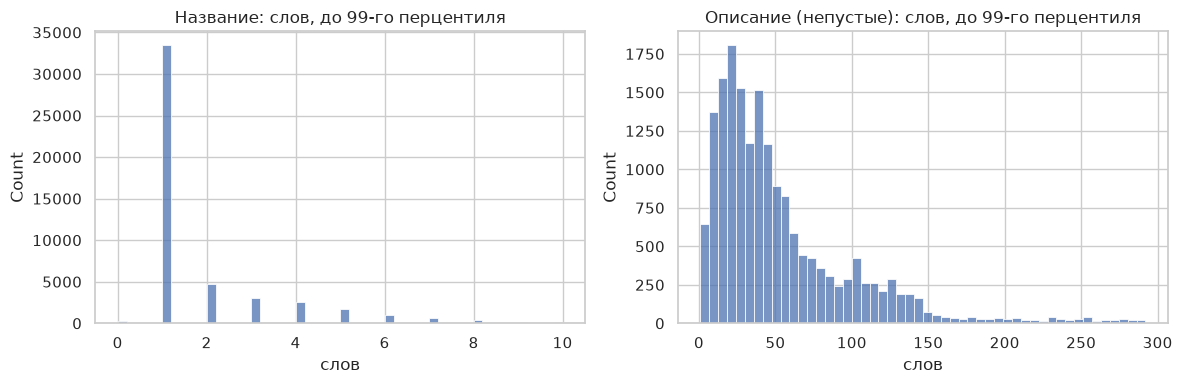

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(
    axes, ["name_words", "desc_words"], ["Название", "Описание (непустые)"]
):
    s = lengths[col].dropna()
    sns.histplot(s[s <= s.quantile(0.99)], bins=50, ax=ax)
    ax.set(title=f"{title}: слов, до 99-го перцентиля", xlabel="слов")
plt.tight_layout()
plt.show()

In [12]:
cards_dom.loc[
    lengths["desc_chars"].nlargest(3).index, ["imt_name", "subj_name", "description"]
]

,imt_name,subj_name,description
41407,"Блузка женская ""Tracy"", большие размеры",Блузки,Милые наши покупательницы! Мы от души благодарим Вас за долгие годы верности нашему бренду! И с удовольствием дарим вам более 60% ассортимента по ...
41402,"Блузка женская ""Nancy"",большие размеры",Блузки,Милые наши покупательницы! Мы от души благодарим Вас за долгие годы верности нашему бренду! И с удовольствием дарим вам более 60% ассортимента по ...
120006,"Футболка женская ""Gloria"", большие размеры",Футболки,"Базовая модель для вашего гардероба. Отличный всесезонный вариант. Весной и летом станет основным элементом вашего образа, а осенью-зимой оставит ..."


**Вывод: домен и длина текстов**

- После фильтрации по «Одежде» и «Обуви» остаётся 56 503 строки и **48 489 карточек** (36 965 — одежда, 11 524 — обувь). Предметных категорий в домене 104, только 5 из них содержат 1–2 карточки, так что хвост редких категорий почти ушёл вместе с другими корнями. Самые частые категории — «Платья», «Футболки», «Брюки», «Блузки», «Костюмы», «Туфли».
- **Описания нет у 62.7% карточек домена** (по всему каталогу — 29%), даже с учётом того, что для каждой карточки выбрана строка с самым длинным описанием. Для большинства товаров текст для поиска будет собираться только из названия, категории и атрибутов.
- **Названия предельно короткие:** медиана — 1 слово и 8 символов, 90-й перцентиль — 4 слова, максимум — 100 символов. У многих карточек `imt_name` фактически повторяет категорию («Платье»). Встречаются и пустые названия (min = 0).
- **Описания** (по 18 087 непустым): медиана — 39 слов / 283 символа, 90-й перцентиль — 122 слова, 99-й — 292 слова. Длиннее 200 слов — 3.1%, длиннее 350 — 0.4%. Максимум ровно 5 000 символов, похоже на обрезку при выгрузке. Лимит модели в 512 токенов потребует обрезки лишь у небольшой доли описаний. Точную долю посчитаем токенизатором выбранной модели.
- **Выбросы — это рекламные шаблоны, а не описание товара:** самые длинные тексты начинаются с обращения бренда к покупательницам и повторяются у разных моделей одного бренда. Такие тексты размывают эмбеддинг, их нужно выявить при очистке.
- **Следствие для `product_text`:** описание обязательно ставить **после** названия и категории, чтобы смысловое ядро не утонуло в длинных текстах. При коротких названиях атрибуты (бренд, цвет) могут оказаться главным источником различий между товарами.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Анализ длин сделан на правильном уровне - уже по отфильтрованным и дедуплицированным карточкам, с перцентилями и отдельно для непустых описаний. Наблюдения точные: максимум ровно 5 000 символов похож на обрезку при выгрузке, а самые длинные тексты оказываются рекламными шаблонами бренда. Вывод о порядке полей в <code>product_text</code> (описание в конце, чтобы смысловое ядро не терялось при обрезке) напрямую следует из этих цифр. Так и должен работать EDA.
</div>

In [13]:
for r in cards_dom[has_desc].sample(20, random_state=SEED).itertuples():
    print(
        f"[{r.subj_name}] {r.imt_name!r} | бренд: {r.brand_name} | "
        f"цвет: {r.nm_colors_names} | артикул: {r.vendor_code}"
    )
    print(f"    {r.description[:300]}\n")

print("Без описания:")
print(
    cards_dom.loc[~has_desc, ["imt_name", "subj_name", "brand_name", "nm_colors_names"]]
    .sample(10, random_state=SEED)
    .to_string()
)

[Ветровки] 'Ветровка из хлопка' | бренд: L.A.G. | цвет: бежевый | артикул: galina2У-16Ветровках/б1803светлбеж
    Комфортная и стильная ветровка из хлопка незаменима для прохладных дней! Удлиненный крой, кулиски на талии для большего облегания, застежка молния закрыта планкой на кнопках. Рукав можно подвернуть при помощи патов до  длины 3/4. Длина 80 см. Рукав 63 см. Замеры  для 52 размера.

[Босоножки] 'Босоножки женские Thorpeness' | бренд: BALDI | цвет: черный | артикул: Thorpenessblack
    Удобные женские босоножки от Baldi

[Шорты] 'Шорты' | бренд: TITOY | цвет: темно-синий | артикул: П-0024
    Юбка - шорты ( шорты ) школьные для девочек из поликоттона ( хлопок смесовый ) темно - синего цвета. Посадка высокая, свободная, талия фиксируется резинкой и поясом, глубина посадки варьируется лямками ( сзади пришивные перекрещивающиеся, впереди застегиваются на пуговицы, пуговицы при необходимости

[Кеды] 'Кеды кожаные' | бренд: MAGMA | цвет: черный | артикул: GSA410/черный
    Кеды мужс

In [14]:
PATTERNS = {
    "html": r"<[^>]+>|&[a-z]+;|&#\d+;",
    "url": r"https?://|www\.",
    "спецсимволы": r'[^\w\s.,:;!?()\-–—«»"\'/%+№*°]',
    "повторы пунктуации": r"[!?]{3,}|\.{4,}|[*_=~-]{3,}",
    "коды с цифрами": r"\b(?=\w*\d)(?=\w*[^\W\d])\w{4,}\b",
}
texts = {
    "imt_name": cards_dom["imt_name"].astype(object),
    "description": desc.dropna().astype(object),
}
display(
    pd.DataFrame(
        {
            col: {name: s.str.contains(p).mean() * 100 for name, p in PATTERNS.items()}
            for col, s in texts.items()
        }
    )
    .round(2)
    .rename_axis("% текстов")
)

print(
    "Частые спецсимволы:",
    texts["description"]
    .str.findall(PATTERNS["спецсимволы"])
    .explode()
    .value_counts()
    .head(15)
    .to_dict(),
)

vendor = cards_dom["vendor_code"].str.lower().str.strip()
name_low = cards_dom["imt_name"].str.lower()
print(
    f"Артикул поставщика в названии: "
    f"{np.mean([bool(v) and v in n for v, n in zip(vendor, name_low)]):.1%}"
)

print(
    f"Карточек с неуникальным описанием: "
    f"{desc.dropna().duplicated(keep=False).mean():.1%}"
)
print("\nСамые частые названия:")
cards_dom["imt_name"].value_counts().head(10)

,imt_name,description
% текстов,,
html,0.00,0.03
url,0.00,0.00
спецсимволы,0.10,0.49
повторы пунктуации,0.01,0.52
коды с цифрами,0.41,3.59


Частые спецсимволы: {'|': 88, '•': 43, '&': 42, '―': 11, '”': 9, '=': 9, '“': 8, '#': 5, '@': 5, '<': 4, '>': 4, '\\': 4, '·': 4, '`': 3, '’': 3}
Артикул поставщика в названии: 0.1%
Карточек с неуникальным описанием: 35.5%

Самые частые названия:


imt_name
Платье       4212
Футболка     2524
Брюки        1898
Туфли        1422
Ботинки      1124
Блузка       1052
Джинсы       1032
Рубашка      1021
Юбка          981
Кроссовки     887
Name: count, dtype: int64

In [15]:
brands = cards_dom.loc[cards_dom["brand_name"].str.strip().ne(""), "brand_name"]
print(
    f"Брендов: {brands.nunique()}, "
    f"медиана карточек на бренд: {brands.value_counts().median():.0f}"
)
print(
    f"Бренд в названии: {np.mean([b.lower() in n for b, n in zip(cards_dom['brand_name'], name_low) if b]):.1%}"
)

has_color = cards_dom["nm_colors_names"].str.strip().ne("")
stem = (
    cards_dom.loc[has_color, "nm_colors_names"]
    .str.split(",")
    .str[0]
    .str.strip()
    .str.lower()
    .str[:-2]
)
print(
    f"\nКарточек с цветом: {has_color.mean():.1%}, уникальных цветов: {stem.nunique()}"
)
for col in ("imt_name", "description"):
    text = cards_dom.loc[has_color, col].str.lower()
    print(f"Цвет упомянут в {col}: {np.mean([s in t for s, t in zip(stem, text)]):.1%}")

colors_per_card = df_dom.groupby("imt_id")["nm_colors_names"].nunique()
print(f"Карточек с разными цветами у артикулов: {(colors_per_card > 1).mean():.1%}")

Брендов: 3915, медиана карточек на бренд: 4
Бренд в названии: 1.2%

Карточек с цветом: 98.2%, уникальных цветов: 237
Цвет упомянут в imt_name: 1.5%
Цвет упомянут в description: 4.2%
Карточек с разными цветами у артикулов: 8.7%


**Вывод: качество текста, бренд и цвет**

- **Текст в целом чистый.** HTML встречается в 0.03% описаний, URL нет, спецсимволы (`|`, `•`, `&`, типографские кавычки и тире) — в 0.5%, повторы пунктуации — в 0.5%. Коды с цифрами есть в 3.6% описаний и 0.4% названий, в основном это размеры, составы и модели («52 размера», «95% хлопок»), а не мусор. Артикул поставщика в названии почти не встречается (0.1%).
- **Что учесть в функции очистки:** удалить HTML-теги и сущности, заменить `|`, `•` и прочие спецсимволы пробелом, привести типографские кавычки к единому виду, заменить «ё» на «е», свернуть повторы пунктуации и пробелов. Пробелы вокруг дефисов («темно - синего») не трогаем: одним правилом их не отличить от тире в предложении, а токенизаторам они не мешают. Регистр не меняем: TF-IDF понижает его сам. Очистка одна и та же для товаров и запросов.
- **`vendor_code` в текст не берём:** это служебные строки вроде `galina2У-16Ветровках/б1803светлбеж`, смысла они не несут, а словарь TF-IDF засоряют.
- **Шаблонные описания:** у 35.5% карточек с описанием оно не уникально. Бренды копируют один текст («Милые наши покупательницы!…») на разные модели. Такое описание не различает товары, поэтому его ставим в конец `product_text`.
- **Название часто совпадает с категорией:** самые частые названия — «Платье» (4 212), «Футболка» (2 524), «Брюки» (1 898). У этих карточек `imt_name` и `subj_name` несут одну и ту же информацию. При этом `subj_name` иногда шире названия («Плащ» лежит в «Куртках», юбка-шорты — в «Шортах»), поэтому категорию в тексте оставляем.
- **Бренд:** 3 915 брендов, медиана — 4 карточки на бренд, в названии бренд упомянут у 1.2% карточек. Бренд — точный идентификатор, а не смысловой признак. Включать ли его в текст эмбеддинга, решим по тому, упоминают ли бренды в запросах.
- **Цвет:** заполнен у 98.2% карточек, 237 уникальных значений, в названии упомянут только у 1.5%, в описании — у 4.2%. **Цвет не дублирует название и включается в `product_text`.** У 8.7% карточек артикулы разных цветов, поэтому при дедупликации цвета объединяем по всем артикулам карточки, а не берём из одной строки.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Качество текста измерено, а не оценено «на глаз»: словарь регулярных выражений по типам шума и доля текстов с каждой проблемой - очень удобный формат. Интересная альтернатива авторскому подходу - ты проверил, дублирует ли цвет и бренд название и описание, и на этом основании включил цвет в текст. Плюс заметил, что у 8.7% карточек артикулы разных цветов, и сразу сделал вывод, что цвета нужно агрегировать по всем артикулам. Этот нюанс легко пропустить.
</div>

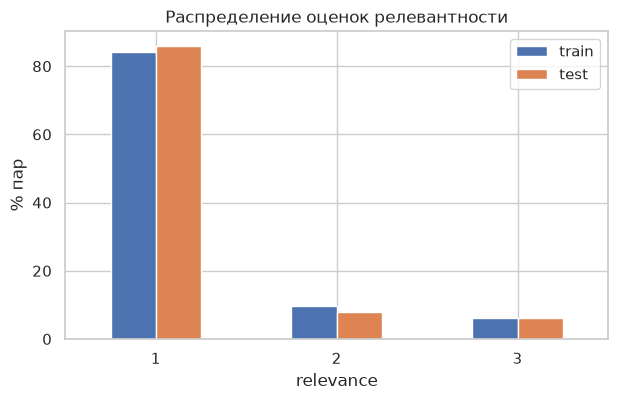

,n_items,n_rel,max_rel
count,700.00,700.00,700.0
mean,16.36,2.57,3.0
std,5.42,2.47,0.0
min,1.00,1.00,3.0
25%,14.00,1.00,3.0
50%,16.00,1.00,3.0
75%,19.00,3.00,3.0
max,31.00,17.00,3.0


Запросов без товаров с relevance ≥ 2: 0


In [16]:
rel_dist = pd.DataFrame(
    {
        name: q["relevance"].value_counts(normalize=True).sort_index() * 100
        for name, q in [("train", queries_train), ("test", queries_test)]
    }
)
ax = rel_dist.plot.bar(rot=0, figsize=(7, 4))
ax.set(xlabel="relevance", ylabel="% пар", title="Распределение оценок релевантности")
plt.show()

q_stats = queries_train.groupby("query_id")["relevance"].agg(
    n_items="size", n_rel=lambda r: (r >= 2).sum(), max_rel="max"
)
display(q_stats.describe().round(2))
print(f"Запросов без товаров с relevance ≥ 2: {(q_stats['n_rel'] == 0).sum()}")

In [17]:
q_text = queries_train.drop_duplicates("query_id")["query_text"]
print(
    "Длина запроса в словах:",
    q_text.str.split().str.len().describe().round(1).to_dict(),
)
print(*q_text.sample(15, random_state=SEED), sep="\n")

q_low = q_text.str.lower().astype(object)
brand_set = {b.lower() for b in brands.unique() if len(b) >= 4}
# Бренд ищем целым словом: не внутри другого слова (ревью v1)
BRAND_RE = re.compile(
    r"(?<!\w)(?:"
    + "|".join(sorted(map(re.escape, brand_set), key=len, reverse=True))
    + r")(?!\w)"
)
color_set = {s for s in stem.unique() if len(s) >= 3}
print(
    f"Запросов с упоминанием бренда: подстрокой "
    f"{q_low.map(lambda q: any(b in q for b in brand_set)).mean():.1%}, "
    f"целым словом {q_low.map(lambda q: bool(BRAND_RE.search(q))).mean():.1%}"
)
# Цвет - по основе без окончания («черн» в «черное»), поэтому подстрокой
print(
    f"Запросов с упоминанием цвета: "
    f"{q_low.map(lambda q: any(c in q for c in color_set)).mean():.1%}"
)

top_pairs = queries_train[queries_train["relevance"] == 3].merge(
    cards_dom[["imt_id", "imt_name", "description"]],
    left_on="item_id",
    right_on="imt_id",
)
literal = [
    q.lower() in f"{n} {d}".lower()
    for q, n, d in zip(
        top_pairs["query_text"], top_pairs["imt_name"], top_pairs["description"]
    )
]
print(f"Запрос дословно входит в текст карточки (rel = 3): {np.mean(literal):.1%}")

Длина запроса в словах: {'count': 700.0, 'mean': 2.7, 'std': 0.9, 'min': 2.0, '25%': 2.0, '50%': 2.0, '75%': 3.0, 'max': 7.0}
топы cop copine
худи mego as
бриджи зуавы
кожаные мокасины
кожаные сабо с открытым мысом
классические джинсовые джинсы
шубы натуральные на пуговицах
тапочки asd
тапочки t taccardi
кигуруми londe
джеггинсы утягивающие
дышащий дутики
мужские резиновые сапоги
прямые жакеты
пальто crockid
Запросов с упоминанием бренда: подстрокой 35.9%, целым словом 31.0%
Запросов с упоминанием цвета: 17.0%
Запрос дословно входит в текст карточки (rel = 3): 6.6%


**Вывод: разметка**

- **Шкала фактически 1–3, оценки 0 нет.** Распределение сильно несбалансировано: оценка 1 — 84% пар в train и 86% в test, 2 — около 10% и 8%, 3 — около 6% в обеих выборках. Распределения train и test совпадают. Оценка 1 соответствует кандидатам, которые асессор счёл неподходящими или слабо подходящими. **Порог бинаризации — `RELEVANCE_THRESHOLD = 2`**: релевантными считаем товары с оценкой 2 и 3. При пороге 1 релевантными оказались бы все размеченные товары.
- **Товаров на запрос:** в среднем 16.4 (от 1 до 31). Релевантных (≥ 2) — медиана 1, среднее 2.6, максимум 17. У каждого запроса есть хотя бы один товар с оценкой 3, запросов без релевантных товаров нет.
- **Потолок метрик:** при одном релевантном товаре Precision@5 не может превысить 0.2, а Precision@10 — 0.1 даже у идеальной системы. Поэтому ключевыми считаем **NDCG@10** (использует всю шкалу 1–3), **Recall@10** и **MRR**, а Precision@K интерпретируем с учётом этого ограничения.
- **Запросы короткие и пользовательские:** 2–7 слов, медиана 2. Типичная структура — «категория + уточнение»: назначение или фасон («мужские резиновые сапоги», «кожаные сабо с открытым мысом»), либо бренд, часто латиницей («тапочки t taccardi», «пальто crockid»). Встречаются разговорные и неточные формулировки («дышащий дутики», «классические джинсовые джинсы»).
- **Бренд упомянут в 31% запросов, цвет — в ~17%.** Бренд ищется целым словом: поиск подстрокой давал 36%, но часть совпадений приходилась на бренды внутри обычных слов. Цвет ищется по основе слова подстрокой, это оценка сверху. Для брендовых запросов важно точное совпадение, поэтому **бренд включаем в `product_text`**, и он же будет сильной стороной лексического поиска. Цвет тоже включаем.
- **Задача действительно query-to-item, а не item-to-item:** дословно запрос входит в текст карточки лишь в 6.6% пар с оценкой 3. Лексический поиск не получает тривиального преимущества, но на брендовых запросах, скорее всего, будет сильнее семантического. Это кандидат на гибридный поиск.

### Итоговые решения по данным

1. **Уровень индексации — карточка `imt_id`.** Для каждой карточки оставляем строку с самым длинным описанием, а цвета объединяем по всем её артикулам.
2. **Домен — корневые категории «Одежда» и «Обувь»:** 48 489 карточек, 100% пула асессоров и релевантных товаров разметки.
3. **Пропуски:** карточки без описания (62.7%) не удаляем, текст для них собираем из названия, категории и атрибутов, а флагом `has_description` отмечаем для анализа ошибок. Удаляем только карточки без названия и без описания одновременно.
4. **Очистка:** HTML, спецсимволы, типографика, «ё» → «е», повторы пунктуации и пробелов. `vendor_code` не используем.
5. **Шаблон `product_text` (базовый):** `название. категория. бренд. цвета. описание`. Описание стоит в конце, чтобы длинные и шаблонные тексты не вытесняли смысловое ядро при обрезке по лимиту модели. Варианты для экспериментов — без описания и без бренда.
6. **Оценка:** порог `relevance ≥ 2`; основные метрики — NDCG@10, Recall@10, MRR, дополнительные — Precision@5, HitRate@K; K ∈ {1, 3, 5, 10}.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Разметка разобрана очень вдумчиво. Замечено, что оценки 0 фактически нет, и порог 2 выбран осознанно: при пороге 1 релевантными стали бы все размеченные пары. Отдельно отмечу оценку потолка Precision@K при одном релевантном товаре и проверку, насколько часто запрос дословно входит в текст карточки (6.6%) - это хороший аргумент, что задача действительно query-to-item. Итоговый список решений по данным получился конкретным, и каждое решение подкреплено цифрой из анализа.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Небольшие замечания и рекомендации💡:</b> Упоминание бренда в запросе ищется подстрокой (<code>w in q</code>), поэтому короткие бренды из 4-5 букв могут совпадать с частью обычного слова. Ты сам пишешь, что оценка приблизительная, и это честно. Но дальше этот же признак используется для сегментации в неделе 3, так что его стоит сделать точнее: например, искать бренд по границам слов (<code>re.search(rf"\b{re.escape(b)}\b", q)</code>) или по пересечению токенов запроса с токенами бренда. Интересно будет посмотреть, изменится ли доля брендовых запросов.
</div>

<div class="alert alert-info">
<b>Бренд теперь ищется целым словом через одно регулярное выражение (<code>BRAND_RE</code>, границы по <code>(?&lt;!\w)</code> / <code>(?!\w)</code>, чтобы корректно работали бренды с точками и дефисами). Доля брендовых запросов снизилась с 35.9% до 31.0% (217 из 700): часть совпадений подстрокой была ложной. Цвет оставлен подстрокой: там ищется основа слова без окончания.
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v2 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Исправлено, и даже аккуратнее, чем я предлагал: одно общее регулярное выражение с сортировкой брендов по длине и границами <code>(?&lt;!\w)</code> / <code>(?!\w)</code>, которые не ломаются на брендах с точками и дефисами. Очень хорошо, что ты вывел обе оценки рядом (35.9% подстрокой против 31.0% целым словом) - так сразу видно, сколько было ложных совпадений. Решение оставить цвет подстрокой тоже обосновано: там ищется основа без окончания. Выводы по разметке и сегментации обновлены.
</div>

---

## Неделя 2 — базовый пайплайн и оценка качества

**Цель:** оперевшись на результаты EDA, создать работающий поиск и получить первые метрики качества.

Прежде чем реализовывать семантический поиск, основанный на эмбеддингах, нужно проверить, как справляется более простая модель, опирающаяся на TF-IDF. Простая модель нужна как baseline, без этой точки отсчёта результат невозможно интерпретировать.


### 1. Подготовка данных


Реализуйте решения недели 1:

1. Отфильтруйте выбранные категории.
2. Дедуплицируйте строки по `imt_id`. Сформулируйте правило, по которому будете определять, какую строку оставить. К примеру, можете оставить строку с самым информативным описанием. Ответ обоснуйте.
3. Отбросьте карточки, у которых пусты одновременно и `imt_name`, и `description`.
4. Напишите функцию очистки текста.
5. Соберите единый текст карточек в отдельной колонке `product_text`.

In [18]:
import html

SPECIAL_RE = re.compile(r'[^\w\s.,:;!?()\-–—«»"\'/%+№*°]')
TEMPLATE = ["imt_name", "subj_name", "brand_name", "colors", "description"]


def clean_text(text: str) -> str:
    """Очищает текст товара или запроса от разметки и мусорных символов."""
    text = html.unescape(text).replace("ё", "е").replace("Ё", "Е")
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[“”„]", '"', text)
    text = SPECIAL_RE.sub(" ", text)
    text = re.sub(r"([!?.,*_=~-])\1+", r"\1", text)
    return re.sub(r"\s+", " ", text).strip()


def build_product_text(df: pd.DataFrame, fields: list[str]) -> pd.Series:
    """Склеивает непустые поля карточки через явный разделитель без повторов."""
    return df[fields].apply(
        lambda row: ". ".join(dict.fromkeys(filter(None, row))), axis=1
    )

In [19]:
df_dom = df_raw[df_raw["subj_root_name"].isin(DOMAIN_ROOTS)]

# Все цвета карточки по её артикулам, без повторов и с сохранением порядка
colors = (
    df_dom.assign(color=df_dom["nm_colors_names"].str.split(","))
    .explode("color")
    .assign(color=lambda d: d["color"].str.strip().str.lower())
    .query('color != ""')
    .groupby("imt_id")["color"]
    .agg(lambda s: ", ".join(dict.fromkeys(s)))
    .rename("colors")
)

# Одна строка на карточку: с самым длинным описанием (nm_id - для детерминизма)
catalog = (
    df_dom.assign(desc_len=df_dom["description"].str.len())
    .sort_values(["desc_len", "nm_id"], ascending=[False, True])
    .drop_duplicates("imt_id")
    .join(colors, on="imt_id")[["imt_id", "subj_root_name"] + TEMPLATE]
)

catalog[TEMPLATE] = catalog[TEMPLATE].apply(
    lambda s: s.fillna("").astype(object).map(clean_text)
)

empty = catalog["imt_name"].eq("") & catalog["description"].eq("")
catalog = catalog[~empty].reset_index(drop=True)
catalog["has_description"] = catalog["description"].ne("")
catalog["product_text"] = build_product_text(catalog, TEMPLATE)

print(f"Строк в домене: {len(df_dom)}, карточек: {catalog.shape[0] + empty.sum()}")
print(f"Отсеяно без названия и описания: {empty.sum()}")
print(
    f"Итоговый каталог: {len(catalog)}, "
    f"с описанием: {catalog['has_description'].mean():.1%}"
)
catalog.to_parquet(DATA_DIR / "catalog.parquet", index=False)

Строк в домене: 56503, карточек: 48489
Отсеяно без названия и описания: 113
Итоговый каталог: 48376, с описанием: 37.4%


In [20]:
for text in catalog["product_text"].sample(8, random_state=SEED):
    print(text[:250], end="\n\n")

Джинсы женские 04J. Джинсы. Grunge John Orchestra. Explosion. синий

Брюки женские. Брюки. Zolla. черный. Брюки-джоггеры на кулиске гарантируют максимальный комфорт. Они идеально впишутся не только в повседневный образ, но и подойдут для офиса с нестрогим дресс-кодом. Модель дополнена боковыми карманами и манжетами по

Джемпер. Джемперы. Converse. серый

Футболка "RAY". Футболки. Ray Style. черный

Брюки спортивные женские/. Брюки. Moliza. морковный. На фотографии параметры модели: рост 160 см, размер 42/XS. Длина по внутреннему шву 71 см. Внешняя длина 99 см.

Кроссовки. Adal. черный

Свитшот. Свитшоты. Mark Formelle. бордовый

Босоножки. BESMODA. розовый



**Вывод: подготовка данных**

- Фильтр по «Одежде» и «Обуви»: 56 503 строки → дедупликация по `imt_id` → 48 489 карточек. Для каждой карточки оставлена строка с самым длинным описанием (при равной длине — с меньшим `nm_id`, для воспроизводимости). Цвета объединены по всем артикулам карточки.
- Отсеяно **113 карточек (0.2%)** без названия и описания одновременно, это не проблема качества каталога. **Итоговый каталог — 48 376 карточек**, описание есть у 37.4%. Карточки без описания оставлены, у них есть флаг `has_description`.
- Очистка: HTML-сущности и теги, типографские кавычки, «ё» → «е», спецсимволы, повторы пунктуации и пробелов. Регистр сохранён: TF-IDF понижает его сам, а трансформерам он не мешает.
- `product_text = название. категория. бренд. цвета. описание`. Пустые поля и повторяющиеся значения пропускаются (например, когда название совпадает с категорией). Ручная проверка на 8 примерах артефактов не выявила.
- Каталог сохранён в `data/catalog.parquet` для повторного использования и Streamlit-приложения.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Подготовка данных полностью соответствует решениям недели 1. Дедупликация детерминирована (длина описания, при равенстве - <code>nm_id</code>), цвета собраны по всем артикулам карточки, отброшены только карточки без названия и описания одновременно. <code>build_product_text</code> через <code>dict.fromkeys(filter(None, row))</code> - элегантное решение: пустые поля пропускаются, а повторы вроде «Платье. Платье» убираются одной строкой. Каталог сохранён на диск для приложения - это хорошая привычка.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Небольшие замечания и рекомендации💡:</b> Небольшое улучшение для <code>clean_text</code>: добавь замену «ё» на «е». В карточках и запросах одно и то же слово может быть написано по-разному («чёрный» / «черный»), и для TF-IDF это два разных токена. Для эмбеддингов это менее критично, но единая нормализация не повредит ни одному из подходов.
</div>

<div class="alert alert-info">
<b>Добавил в <code>clean_text</code> замену «ё» на «е» (и «Ё» на «Е»). Очистка общая для карточек и запросов, поэтому нормализация одинакова для TF-IDF и эмбеддингов. Все эмбеддинги пересчитаны, метрики в выводах обновлены.
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v2 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Нормализация «ё» → «е» добавлена в общую <code>clean_text</code>, поэтому одинаково действует на карточки и запросы, на TF-IDF и на эмбеддинги. Отдельный плюс за то, что после правки пересчитаны эмбеддинги и обновлены все цифры в выводах, а не только код.
</div>

### Каталог для поиска и оценки

1. Посчитайте метрику при поиске по всему отфильтрованному каталогу. Например, вычислите NDCG@10 лексическим поиском на 100 запросах.
2. Выведите топ-10 для одного запроса и отметьте, какие товары есть в разметке, а каких нет. Выясните, в чём проблема.
3. Ограничьте каталог оценки пулом асессоров: возьмите из `wb_products_dedup.parquet` только список `imt_id` и оставьте в своём подготовленном каталоге пересечение с ним. Тексты и все признаки — ваши, из шага 1.
4. Пересчитайте метрику и сравните результаты.
5. Посмотрите на распределение `relevance` и число оценённых товаров на запрос. Проверьте, у всех ли запросов есть товары с `relevance` ≥ 2.

In [21]:
catalog_eval = catalog[catalog["imt_id"].isin(pool_ids)].reset_index(drop=True)
print(
    f"Пул асессоров: {pool_ids.nunique()}, "
    f"из него в каталоге: {len(catalog_eval)}, "
    f"с описанием: {catalog_eval['has_description'].mean():.1%}"
)

# Не потеряли ли размеченные товары при подготовке (порог >= 2 - см. раздел 3)
for name, q in [("train", queries_train), ("test", queries_test)]:
    in_eval = q["item_id"].isin(catalog_eval["imt_id"])
    has_rel = q[in_eval].groupby("query_id")["relevance"].max().ge(2)
    print(
        f"{name}: пар вне каталога {(~in_eval).sum()}, "
        f"запросов без релевантных товаров: "
        f"{q['query_id'].nunique() - has_rel.sum()}"
    )

Пул асессоров: 4256, из него в каталоге: 4256, с описанием: 77.5%
train: пар вне каталога 0, запросов без релевантных товаров: 0
test: пар вне каталога 0, запросов без релевантных товаров: 0


**Вывод: каталог оценки**

- Каталог оценки — пересечение подготовленного каталога с пулом асессоров: **4 256 карточек**, весь пул сохранился. Тексты и признаки взяты из нашего каталога, из `wb_products_dedup.parquet` использован только список `imt_id`.
- Ни одна размеченная пара не потерялась при подготовке. У всех 700 запросов train и 300 запросов test в каталоге оценки есть хотя бы один товар с relevance ≥ 2.
- **Смещение каталога оценки:** описание есть у 77.5% карточек пула против 37.4% во всём каталоге. Оценка идёт на текстово более богатых товарах, чем в реальном каталоге, поэтому в продакшене качество, особенно семантического поиска, может оказаться ниже. Это ограничение фиксируем в выводах.
- Сравнение метрик при поиске по всему каталогу (48 376) и по пулу (4 256) — в разделе 3.

### 2. Модели поиска

Реализуйте два поисковых движка с одинаковым интерфейсом. Это позволит прогнать оба через одну функцию оценки:

In [22]:
def search_xxx(query: str, top_k: int = 10) -> pd.DataFrame:
    """Возвращает top_k товаров с колонками imt_id, imt_name, subj_name, score."""


Реализуйте лексический baseline на TF-IDF:

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

TFIDF_PARAMS = {"ngram_range": (1, 2), "max_features": 100_000, "sublinear_tf": True}


def top_k_results(scores: np.ndarray, df: pd.DataFrame, top_k: int) -> pd.DataFrame:
    """Возвращает top_k товаров с наибольшим скором.

    При равном скоре порядок - по возрастанию imt_id, чтобы выдача
    не зависела от реализации сортировки (у карточек-близнецов скоры равны).
    """
    idx = np.lexsort((df["imt_id"].to_numpy(), -scores))[:top_k]
    return (
        df.iloc[idx][["imt_id", "imt_name", "subj_name"]]
        .assign(score=scores[idx])
        .reset_index(drop=True)
    )


def build_lexical(df: pd.DataFrame):
    """Строит TF-IDF-индекс по product_text и возвращает функцию поиска."""
    vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
    matrix = vectorizer.fit_transform(df["product_text"])

    def search(query: str, top_k: int = 10) -> pd.DataFrame:
        query_vec = vectorizer.transform([clean_text(query)])
        return top_k_results((matrix @ query_vec.T).toarray().ravel(), df, top_k)

    return search


search_lexical = build_lexical(catalog_eval)
search_lexical("кожаные мокасины", top_k=5)

,imt_id,imt_name,subj_name,score
0,10029048,Мокасины детские,Мокасины,0.238374
1,10135083,Мокасины 236/36-40,Мокасины,0.216283
2,10042990,Мокасины мужские летние натуральная кожа,Мокасины,0.211095
3,10066145,Мокасины/Туфли/Сменка в школу,Мокасины,0.209561
4,10066151,Мокасины/Туфли/Сменка/Школа,Мокасины,0.208846


Реализуйте семантический поиск:

In [24]:
import hashlib

from sentence_transformers import SentenceTransformer

MODEL_NAME = "intfloat/multilingual-e5-small"
QUERY_PREFIX, PASSAGE_PREFIX = "query: ", "passage: "  # требование e5
BATCH_SIZE = 64
EMB_PATH = DATA_DIR / "emb_e5_small.npy"

model = SentenceTransformer(MODEL_NAME)


def encode(texts, prefix: str, progress: bool = False, st_model=None) -> np.ndarray:
    """Кодирует тексты в L2-нормированные эмбеддинги (по умолчанию моделью e5)."""
    return (st_model or model).encode(
        [prefix + t for t in texts],
        batch_size=BATCH_SIZE,
        normalize_embeddings=True,
        show_progress_bar=progress,
    )


def cached_encode(
    path: Path, texts, prefix: str, st_model=None, model_name: str = MODEL_NAME
) -> np.ndarray:
    """Эмбеддинги с кешем в .npy.

    Рядом хранится sha256 от модели, префикса и текстов: если каталог или
    очистка изменились, кеш не совпадёт и эмбеддинги пересчитаются.
    """
    digest = hashlib.sha256("\n".join([model_name, prefix, *texts]).encode()).hexdigest()
    hash_path = path.with_suffix(".sha256")
    if path.exists() and hash_path.exists() and hash_path.read_text() == digest:
        return np.load(path)
    emb_new = encode(texts, prefix, progress=True, st_model=st_model)
    np.save(path, emb_new)
    hash_path.write_text(digest)
    return emb_new


emb = cached_encode(EMB_PATH, catalog["product_text"], PASSAGE_PREFIX)
emb_eval = emb[catalog["imt_id"].isin(pool_ids).to_numpy()]
print(f"Эмбеддинги: {emb.shape}, каталог оценки: {emb_eval.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/756 [00:00<?, ?it/s]

Эмбеддинги: (48376, 384), каталог оценки: (4256, 384)


In [25]:
n_tokens = catalog["product_text"].map(
    lambda t: len(model.tokenizer.tokenize(PASSAGE_PREFIX + t))
)
print(
    f"Лимит модели: {model.max_seq_length} токенов, "
    f"длиннее: {(n_tokens > model.max_seq_length).mean():.2%}, "
    f"медиана: {n_tokens.median():.0f}"
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1351 > 512). Running this sequence through the model will result in indexing errors


Лимит модели: 512 токенов, длиннее: 0.69%, медиана: 20


In [26]:
def build_semantic(
    df: pd.DataFrame,
    doc_emb: np.ndarray,
    st_model=None,
    query_prefix: str = QUERY_PREFIX,
):
    """Возвращает функцию поиска по косинусной близости эмбеддингов."""

    def search(query: str, top_k: int = 10) -> pd.DataFrame:
        query_emb = encode([clean_text(query)], query_prefix, st_model=st_model)[0]
        return top_k_results(doc_emb @ query_emb, df, top_k)

    return search


search_semantic = build_semantic(catalog_eval, emb_eval)
search_semantic("кожаные мокасины", top_k=5)

,imt_id,imt_name,subj_name,score
0,10025541,Мокасины,Мокасины,0.897908
1,10021321,Мокасины из натуральной кожи KristoBad,Мокасины,0.892517
2,10003757,Мокасины Мягкая натуральная кожа,Мокасины,0.891785
3,10042990,Мокасины мужские летние натуральная кожа,Мокасины,0.888425
4,10136688,Мокасины,Мокасины,0.885571


**Вывод: семантический поиск**

- Модель — `intfloat/multilingual-e5-small` (118M параметров, эмбеддинги размерности 384, лимит 512 токенов). Она мультиязычная, обучена на задаче «запрос → документ» и достаточно компактна для CPU. Модель требует префиксов `query:` для запроса и `passage:` для товара. Кодирование одинаковое, векторы L2-нормированы, поэтому скалярное произведение равно косинусному сходству.
- Эмбеддинги посчитаны один раз для всего каталога (48 376 × 384, около 17 минут на CPU) и сохранены в `data/emb_e5_small.npy`. Для каталога оценки используется подмножество строк.
- **Обрезка по лимиту незначительна:** длиннее 512 токенов только 0.69% текстов, медиана — 20 токенов. Выбор модели с большим окном качество заметно не улучшит.
- Поиск ближайших соседей — полный перебор матричным умножением, на каталоге такого размера он занимает миллисекунды. ANN-индексы (FAISS, HNSW) понадобятся при масштабировании на миллионы товаров.
- Первая проверка: по запросу «кожаные мокасины» семантический поиск находит товары с «натуральной кожей» в названии, хотя слова «кожаные» в них нет. TF-IDF такие совпадения не видит.
- Косинусные сходства e5 сжаты в узкий диапазон (~0.88–0.90): интерпретируем порядок в выдаче, а не абсолютное значение скора.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Каталог оценки собран ровно так, как нужно: из пула взят только список <code>imt_id</code>, тексты и признаки твои. Проверено, что ни одна размеченная пара не потерялась. Очень ценное наблюдение про смещение: в пуле описание есть у 77.5% карточек против 37.4% во всём каталоге - это прямо влияет на перенос результатов в продакшен. Для семантики выбрана <code>multilingual-e5-small</code>, а не более привычная MiniLM, и выбор аргументирован: обучение на задаче «запрос → документ», префиксы <code>query:</code>/<code>passage:</code> соблюдены, доля обрезки измерена токенизатором модели. Отдельный плюс за замечание, что косинусные сходства e5 сжаты в узкий диапазон и интерпретировать нужно порядок, а не абсолютный скор.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Небольшие замечания и рекомендации💡:</b> Две инженерные мелочи. Первая: <code>np.argsort(-scores)</code> по умолчанию нестабилен, а у тебя много карточек с одинаковым текстом и, значит, с одинаковым скором. Порядок таких «близнецов» в топе может меняться между запусками и версиями numpy, вместе с ним будут слегка плавать метрики. Лучше явно задать правило при равенстве: <code>np.lexsort((ids, -scores))</code> или <code>kind="stable"</code>. Вторая: эмбеддинги загружаются из кэша только по факту существования файла. Если каталог изменится (например, после правки очистки), в поиск молча попадут старые векторы. Достаточно проверить хотя бы совпадение числа строк, а надёжнее - сохранять рядом хеш списка <code>imt_id</code> и текстов.
</div>

<div class="alert alert-info">
<b><code>top_k_results</code> сортирует через <code>np.lexsort((imt_id, -scores))</code>: при равном скоре порядок по возрастанию <code>imt_id</code>; в гибриде RRF - то же правило (<code>key=(-score, imt_id)</code>). То же сделано в <code>app.py</code>. 
Кеш эмбеддингов идёт через <code>cached_encode</code>: рядом с <code>.npy</code> хранится sha256 от модели, префикса и всех текстов, при несовпадении эмбеддинги пересчитываются.
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v2 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Обе правки сделаны. Порядок при равных скорах теперь детерминирован во всех местах: в <code>top_k_results</code> через <code>np.lexsort</code>, в гибриде через ключ <code>(-score, imt_id)</code> и даже в <code>app.py</code>. Функция <code>cached_encode</code> с sha256 от модели, префикса и текстов - образцовое решение: кэш пересчитывается сам, как только меняется каталог, очистка или модель, и она переиспользуется во всех экспериментах. Именно так кэш и должен работать в реальном проекте.
</div>

Прогоните 3–5 запросов вручную и сравните выдачу обоих подходов. Это самый простой способ поймать грубые ошибки до подсчёта метрик.

In [27]:
for q in (
    queries_train.drop_duplicates("query_id").sample(3, random_state=SEED).itertuples()
):
    labels = queries_train[queries_train["query_id"] == q.query_id].set_index(
        "item_id"
    )["relevance"]
    print(f"\n=== Запрос: {q.query_text}")
    for name, search in [("lexical", search_lexical), ("semantic", search_semantic)]:
        print(name)
        display(
            search(q.query_text, top_k=5).assign(rel=lambda d: d["imt_id"].map(labels))
        )


=== Запрос: топы cop copine
lexical


,imt_id,imt_name,subj_name,score,rel
0,10016977,Топы,Топы,0.307719,1.0
1,10022252,Топ,Топы,0.231267,3.0
2,10022246,Брюки,Брюки,0.204677,NaN
3,10022262,Платье,Платья,0.203931,NaN
4,10022245,Брюки,Брюки,0.191545,NaN


semantic


,imt_id,imt_name,subj_name,score,rel
0,10022252,Топ,Топы,0.867084,3
1,10022566,Топ женский,Топы,0.864230,1
2,10047446,Топ - TROPICO,Топы,0.863031,1
3,10042858,Майка,Топы,0.858846,1
4,10095356,"Топ ""Juliet""",Топы,0.857253,1



=== Запрос: худи mego as
lexical


...

,imt_id,imt_name,subj_name,score,rel
0,10134111,Худи на молнии с капюшоном,Худи,0.850321,3.0
1,10016977,Топы,Топы,0.848252,NaN
2,10070035,Эспадрильи,Эспадрильи,0.838286,NaN
3,10042858,Майка,Топы,0.836047,NaN
4,10142636,Худи Raava,Худи,0.835760,1.0



=== Запрос: бриджи зуавы
lexical


,imt_id,imt_name,subj_name,score,rel
0,10124357,Бриджи Тропики,Бриджи,0.213694,1
1,10096870,Зуавы,Бриджи,0.188442,3
2,10000043,Бриджи/большие размеры/стрейч/ажур,Бриджи,0.173329,1
3,1003861,Бриджи,Бриджи,0.171479,1
4,10005760,Бриджи женские/большого размера/Облегающие брюки/Капри,Бриджи,0.163798,1


semantic


,imt_id,imt_name,subj_name,score,rel
0,10131214,Бриджи / Капри с принтом - крапинки,Бриджи,0.847879,1.0
1,1003861,Бриджи,Бриджи,0.847826,1.0
2,10046070,Бриджи женские,Капри,0.845967,1.0
3,10145729,"Брюки,бирюзовый,58",Брюки,0.844420,NaN
4,10096870,Зуавы,Бриджи,0.842924,3.0


**Вывод: ручное сравнение выдачи**

- **«топы cop copine» (запрос с брендом).** Лексический поиск цепляется за бренд: на 3–5 местах стоят брюки и платье Cop Copine, то есть бренд перевешивает категорию. Товар с оценкой 3 он ставит на 2-е место. Семантический поиск держит категорию (все 5 результатов — топы) и ставит товар с оценкой 3 на 1-е место, но бренд учитывает слабо: остальные топы, судя по всему, других брендов.
- **«худи mego as» (бренд с редким латинским токеном).** Оба подхода ставят на 1-е место товар с оценкой 3. Дальше лексический снова уходит в товары бренда из другой категории (брюки-джоггеры). Семантический выдаёт шум: топы, эспадрильи, майку. Латинский «as» модель, видимо, поняла как произвольный токен и потеряла смысл запроса.
- **«бриджи зуавы» (редкий точный термин).** Лексический поиск находит «Зуавы» (оценка 3) на 2-м месте за счёт точного совпадения редкого слова. Семантический ставит его только на 5-е, выше оказываются «похожие по смыслу» бриджи и капри, а на 4-м месте — брюки.
- **Общая картина:**
  - Семантический поиск лучше удерживает **тип товара** и понимает синонимы (натуральная кожа ↔ кожаные).
  - Лексический лучше работает с **точными редкими словами**: брендами и специфическими названиями («зуавы»).
  - Ошибки двух подходов разного характера, и это аргумент в пользу **гибридного поиска** на неделе 3.
- В выдаче много товаров с `NaN`, не размеченных для запроса. По соглашению они считаются нерелевантными, хотя часть из них (например, «Бриджи женские» с оценкой 1) могла бы подойти пользователю. Это ограничение пулированной разметки.

### 3. Оценка качества решений

Реализуйте метрики Precision@K, Recall@K, MRR, NDCG@K, HitRate@K.

Три ключевые особенности, которые надо учесть при расчёте:

1. Порог бинаризации. Precision@K, Recall@K, MRR, HitRate@K бинарны, а шкала `relevance` — от `0` до `3`. С какой оценки товар считается релевантным? Вынесите порог в параметр, а не константу внутри функции.
2. NDCG считайте по полной шкале 0–3 (`gain = 2^rel - 1`), а не по бинаризованной, иначе теряется смысл градуированной разметки.
3. Неразмеченные товары в выдаче трактуйте как нерелевантные (`relevance_map.get(item_id, 0)`).

Выводы запишите в Markdown-ячейке и рабочем файле Markdown.

In [28]:
RELEVANCE_THRESHOLD = 2
K_VALUES = (1, 3, 5, 10)


def query_metrics(
    ranked_ids: list,
    relevance_map: dict,
    threshold: int = RELEVANCE_THRESHOLD,
    k_values=K_VALUES,
) -> dict:
    """Метрики одного запроса по ранжированному списку item_id."""
    rels = np.array([relevance_map.get(i, 0) for i in ranked_ids])
    is_rel = rels >= threshold
    n_rel = sum(r >= threshold for r in relevance_map.values())
    ideal = np.sort(list(relevance_map.values()))[::-1]

    first = np.flatnonzero(is_rel)
    res = {"mrr": 1 / (first[0] + 1) if first.size else 0.0}
    for k in k_values:
        discounts = 1 / np.log2(np.arange(2, k + 2))
        dcg = ((2 ** rels[:k] - 1) * discounts[: len(rels[:k])]).sum()
        idcg = ((2 ** ideal[:k] - 1) * discounts[: len(ideal[:k])]).sum()
        res[f"precision_at_{k}"] = is_rel[:k].sum() / k
        res[f"recall_at_{k}"] = is_rel[:k].sum() / n_rel if n_rel else 0.0
        res[f"ndcg_at_{k}"] = dcg / idcg if idcg else 0.0
        res[f"hitrate_at_{k}"] = float(is_rel[:k].any())
    return res


def make_golden(queries: pd.DataFrame) -> dict:
    """Golden-сет: {query_id: (query_text, {item_id: relevance})}."""
    return {
        qid: (g["query_text"].iat[0], dict(zip(g["item_id"], g["relevance"])))
        for qid, g in queries.groupby("query_id")
    }


def evaluate(search, golden: dict, top_k: int = max(K_VALUES)) -> pd.DataFrame:
    """Метрики по каждому запросу golden-сета."""
    return pd.DataFrame(
        [
            {
                "query_id": qid,
                "query_text": text,
                **query_metrics(search(text, top_k)["imt_id"].tolist(), rel_map),
            }
            for qid, (text, rel_map) in golden.items()
        ]
    )

In [29]:
m = query_metrics([1, 2, 3], {2: 3, 3: 1, 4: 2}, k_values=(1, 3))
assert m["mrr"] == 0.5 and m["hitrate_at_1"] == 0
assert m["recall_at_3"] == 0.5 and np.isclose(m["precision_at_3"], 1 / 3)
assert 0 < m["ndcg_at_3"] < 1
print("Метрики считаются корректно")

Метрики считаются корректно


In [30]:
golden_train = make_golden(queries_train)
results = {
    name: evaluate(search, golden_train)
    for name, search in [("lexical", search_lexical), ("semantic", search_semantic)]
}
summary = pd.DataFrame(
    {
        name: res.drop(columns=["query_id", "query_text"]).mean()
        for name, res in results.items()
    }
).T
summary.round(4).to_csv("metrics_baseline.csv")

KEY_METRICS = ["ndcg_at_10", "recall_at_10", "mrr", "precision_at_5", "hitrate_at_10"]
print(
    f"Порог: relevance >= {RELEVANCE_THRESHOLD}, "
    f"запросов: {len(golden_train)}, каталог: {len(catalog_eval)}"
)
display(summary[KEY_METRICS].round(3))
summary.T.round(3)

Порог: relevance >= 2, запросов: 700, каталог: 4256


,ndcg_at_10,recall_at_10,mrr,precision_at_5,hitrate_at_10
lexical,0.518,0.533,0.392,0.149,0.661
semantic,0.578,0.790,0.700,0.274,0.914


,lexical,semantic
mrr,0.392,0.700
precision_at_1,0.283,0.587
recall_at_1,0.199,0.388
ndcg_at_1,0.320,0.499
hitrate_at_1,0.283,0.587
precision_at_3,0.200,0.361
recall_at_3,0.361,0.591
ndcg_at_3,0.430,0.576
hitrate_at_3,0.463,0.793
precision_at_5,0.149,0.274


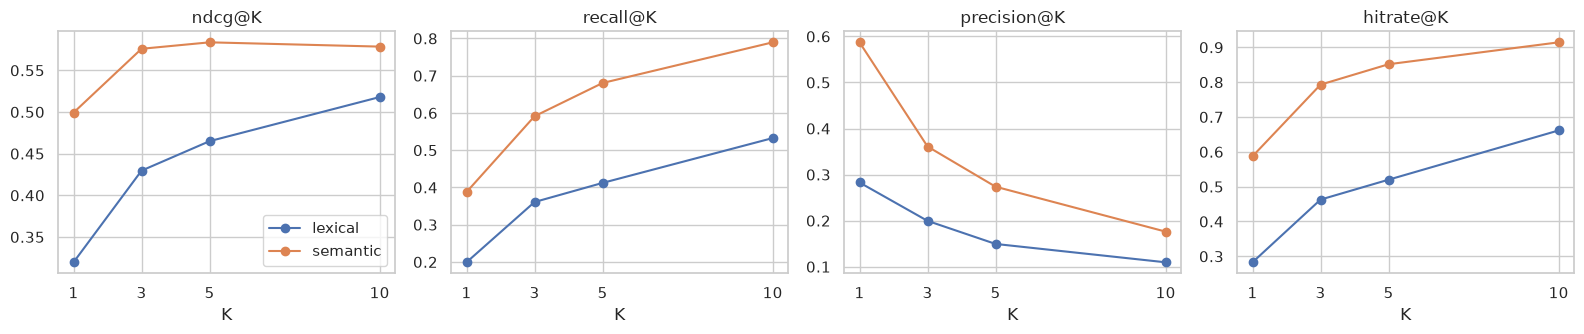

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, metric in zip(axes, ["ndcg", "recall", "precision", "hitrate"]):
    for name in summary.index:
        ax.plot(
            K_VALUES,
            [summary.loc[name, f"{metric}_at_{k}"] for k in K_VALUES],
            marker="o",
            label=name,
        )
    ax.set(title=f"{metric}@K", xlabel="K", xticks=K_VALUES)
axes[0].legend()
plt.tight_layout()
plt.show()

**Вывод: зависимость от K**

- Семантический поиск лучше лексического при всех K по всем метрикам, кривые нигде не пересекаются.
- У семантики NDCG@K выходит на плато уже к K = 3–5 (0.576 → 0.578): основная ценность выдачи сосредоточена в первых позициях. У лексики NDCG@K растёт до K = 10, потому что хвост топа заполняется размеченными товарами с оценкой 1 (подробнее о смещении пула — в базовом сравнении ниже).
- Precision@K падает с ростом K у обоих подходов: на запрос приходится мало релевантных товаров, и это ограничение разметки, а не алгоритма.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Метрики реализованы правильно: NDCG по полной шкале с <code>gain = 2^rel - 1</code> и идеальным ранжированием по всем оценкам запроса, порог вынесен в параметр, неразмеченные товары считаются нерелевантными. Мини-тест на игрушечном примере с <code>assert</code> - отличная практика, которой в задании не было. Ручное сравнение выдачи тоже сделано по делу: на трёх запросах ты сразу увидел разный характер ошибок двух подходов (лексика тянет бренд из чужих категорий, семантика теряет редкие термины вроде «зуавы»). Это и есть готовое обоснование гибрида.
</div>

In [32]:
search_lexical_full = build_lexical(catalog)
search_semantic_full = build_semantic(catalog, emb)
sample_ids = pd.Series(list(golden_train)).sample(100, random_state=SEED)
golden_sample = {qid: golden_train[qid] for qid in sample_ids}

display(
    pd.DataFrame(
        {
            (name, scope): evaluate(search, golden_sample)[KEY_METRICS].mean()
            for name, scope, search in [
                ("lexical", "пул", search_lexical),
                ("lexical", "весь каталог", search_lexical_full),
                ("semantic", "пул", search_semantic),
                ("semantic", "весь каталог", search_semantic_full),
            ]
        }
    ).T.round(3)
)

text, rel_map = golden_sample[sample_ids.iat[0]]
print(f"Запрос: {text}")
search_semantic_full(text, 10).assign(
    rel=lambda d: d["imt_id"].map(rel_map),
    in_labels=lambda d: d["imt_id"].isin(rel_map),
)

ndcg_at_10  recall_at_10    mrr  precision_at_5  \
lexical  пул                0.523         0.563  0.377           0.152   
         весь каталог       0.073         0.148  0.061           0.030   
semantic пул                0.559         0.743  0.682           0.252   
         весь каталог       0.205         0.394  0.278           0.092   

                       hitrate_at_10  
lexical  пул                    0.72  
         весь каталог           0.21  
semantic пул                    0.88  
         весь каталог           0.56

Запрос: топы cop copine


,imt_id,imt_name,subj_name,score,rel,in_labels
0,10022243,Топ,Топы,0.870343,NaN,False
1,10022253,Топ,Топы,0.867683,NaN,False
2,10022264,Топ,Топы,0.867210,NaN,False
3,10022252,Топ,Топы,0.867084,3.0,True
4,1009580,Топ,Топы,0.865680,NaN,False
5,1009582,Топ,Топы,0.865680,NaN,False
6,1003736,Топ,Топы,0.865428,NaN,False
7,1009638,Топ,Топы,0.865428,NaN,False
8,10067786,Топы,Топы,0.864545,NaN,False
9,10022566,Топ женский,Топы,0.864230,1.0,True


**Вывод: поиск по всему каталогу против каталога оценки (100 запросов train)**

| Подход | Каталог | NDCG@10 | Recall@10 | MRR | HitRate@10 |
|---|---|---|---|---|---|
| lexical | пул (4 256) | 0.523 | 0.563 | 0.377 | 0.72 |
| lexical | весь (48 376) | 0.073 | 0.148 | 0.061 | 0.21 |
| semantic | пул (4 256) | 0.559 | 0.743 | 0.682 | 0.88 |
| semantic | весь (48 376) | 0.205 | 0.394 | 0.278 | 0.56 |

- При поиске по всему каталогу метрики падают в 2.5–7 раз. Причина не в качестве поиска, а в разметке: оценено около 9% каталога, и топ заполняется неразмеченными товарами, которые автоматически считаются нерелевантными. Например, по запросу «топы cop copine» 8 из 10 результатов — неразмеченные «Топ» из категории «Топы». **Поэтому итоговая оценка ведётся на каталоге, ограниченном пулом асессоров.**
- Порядок подходов при этом сохраняется, а семантика деградирует заметно меньше: HitRate@10 0.56 против 0.21. Её преимущество не артефакт маленького каталога.
- В каталоге есть карточки с одинаковым текстом (одинаковое название, категория, бренд и цвет). Они получают равный скор и занимают несколько позиций топа; порядок между ними фиксирован правилом «по возрастанию `imt_id`». Дедупликация по тексту — кандидат на улучшение.

In [33]:
def label_coverage(search, golden: dict, k: int = 10) -> pd.Series:
    """Доли товаров в топ-k по оценкам разметки (NaN - не размечен)."""
    rels = [
        rel_map.get(i)
        for text, rel_map in golden.values()
        for i in search(text, k)["imt_id"]
    ]
    return (
        pd.Series(rels)
        .value_counts(normalize=True, dropna=False)
        .sort_index()
        .rename(lambda x: "не размечен" if pd.isna(x) else f"rel={int(x)}")
    )


pd.DataFrame(
    {
        name: label_coverage(search, golden_train)
        for name, search in [("lexical", search_lexical), ("semantic", search_semantic)]
    }
).round(3)

,lexical,semantic
rel=1,0.590,0.248
rel=2,0.058,0.096
rel=3,0.052,0.080
не размечен,0.300,0.576


**Вывод: базовое сравнение (train, 700 запросов, каталог оценки 4 256, порог relevance ≥ 2)**

| Метрика | Лексический (TF-IDF) | Семантический (e5-small) |
|---|---|---|
| NDCG@10 | 0.518 | **0.578** |
| Recall@10 | 0.533 | **0.790** |
| MRR | 0.392 | **0.700** |
| Precision@5 | 0.149 | **0.274** |
| HitRate@10 | 0.661 | **0.914** |

- **Семантический поиск лучше по всем метрикам и всем K.** Сильнее всего он выигрывает на первых позициях: MRR 0.700 против 0.392, HitRate@1 0.587 против 0.283. В 59% запросов первый результат релевантен, у TF-IDF — в 28%. В топ-10 семантика находит хотя бы один релевантный товар для 91% запросов против 66% у лексики.
- **Precision@K низкий у обоих подходов, и это ожидаемо:** у медианного запроса один релевантный товар, так что Precision@5 ограничен сверху значением около 0.2–0.3. Поэтому решение принимаем по NDCG@10, Recall@10 и MRR.
- **Разрыв по NDCG@10 (+12%) заметно меньше, чем по Recall@10 (+48%) и MRR (+79%).** Причина в смещении пулированной разметки. В топ-10 лексического поиска 59% товаров размечены оценкой 1 и только 30% не размечены. У семантического 25% товаров с оценкой 1 и 58% неразмеченных. Кандидаты для разметки, по-видимому, отбирались лексически похожим способом, и TF-IDF возвращает их чаще. Оценка 1 по порогу означает «нерелевантен», но в NDCG даёт gain = 1, поэтому NDCG частично вознаграждает лексику за попадание в пул.
- **Метрики семантического поиска, вероятно, занижены:** более половины его выдачи не размечены и по соглашению считаются нерелевантными, хотя часть из них может подходить пользователю. Для честного сравнения нужна доразметка топа семантического поиска. Это рекомендация на следующие шаги.

### Итоги первой итерации

**Что работает:**
- Семантический поиск (e5-small) превосходит TF-IDF по всем метрикам: NDCG@10 0.578 против 0.518, Recall@10 0.790 против 0.533, MRR 0.700 против 0.392. Он удерживает тип товара и понимает синонимы и разные формы слов («кожаные» ↔ «натуральная кожа»).
- Лексический поиск силён на точных редких словах, таких как «зуавы» и бренды латиницей.

**Что работает плохо:**
- Семантика слабо учитывает бренд (31% запросов его содержат) и теряет смысл на коротких латинских токенах («mego as»).
- Лексика не понимает морфологию и синонимы и на брендовых запросах выдаёт товары бренда из чужих категорий.
- Карточки-близнецы с одинаковым текстом занимают несколько мест топа.
- Оценка ограничена пулированной разметкой: неразмеченные товары считаются нерелевантными, и это занижает метрики семантики (58% её топ-10 не размечено).

**Гипотезы для недели 3:**
1. **Гибридный поиск (RRF или взвешенная сумма скоров)** улучшит NDCG@10 и MRR: ошибки двух подходов разного характера (бренды и редкие термины против типа товара и синонимов).
2. **Лемматизация и стоп-слова для TF-IDF** повысят Recall@10 лексического поиска, который сейчас не сопоставляет формы слов («кожаные» / «кожа»). Это также усилит гибрид.
3. **Более сильная русскоязычная модель** (`deepvk/USER-base`) или **дообучение e5 на парах «запрос → товар» из train** улучшат ранжирование внутри категории и работу с брендами.
4. **Шаблон `product_text` с явными метками атрибутов** («бренд: …, цвет: …») поможет модели отличать бренд от описания товара.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Сильнейшая часть недели. Сравнение «весь каталог против пула» наглядно показывает проблему пулированной разметки, а вывод, что порядок подходов при этом сохраняется, делает результат убедительнее. Функция <code>label_coverage</code> - очень ценная находка: доля неразмеченных товаров в топе объясняет, почему разрыв по NDCG@10 заметно меньше, чем по Recall и MRR, и почему NDCG частично вознаграждает лексику за попадание в пул. Это уровень рассуждений, который обычно встречается у опытных специалистов. Итоги итерации и гипотезы на неделю 3 сформулированы явно и вытекают из найденных ошибок.
</div>

---

## Неделя 3 — эксперименты, дообучение и MLflow

**Цель:** проверить гипотезы о том, как можно улучшить систему поиска, зафиксировать эксперименты, дать рекомендации бизнесу.

**Главное правило:** «один эксперимент — одна гипотеза — одно изменение». Если поменять сразу модель, шаблон текста и параметры векторизации, прирост будет невозможно объяснить и повторить.

### 1. Эксперименты по улучшению

Проведите минимум три эксперимента. Оформляйте каждый по схеме:

- **Гипотеза** — ваше предположение и его обоснование. Причины «хочу попробовать другую модель» недостаточно, нужны объяснения такого типа: «Модель с большим окном улучшит поиск товаров с длинными описаниями, потому что в EDA я видел, что X% описаний обрезаются по лимиту токенов».
- **Что меняется** — ровно один компонент относительно baseline.
- **Результат** — метрики на тех же данных, с тем же порогом и теми же K.
- **Вывод** — принимаем или отклоняем гипотезу. Что это говорит о данных?

Придумывайте гипотезы, опираясь на ошибки, которые обнаружили на неделе 2. Если выбранная модель путает смежные категории, попробуйте проверить, решит ли проблему добавление данных из `subj_name` в общий текст карточки. Другой пример: если лексический поиск обходит семантический на точных названиях, а семантический выигрывает у лексического, когда дело доходит до неточных формулировок, — это повод попробовать реализовать гибридный поиск.

Направления для разработки гипотез:

- изменить шаблон `product_text`;
- попробовать другую модель эмбеддингов;
- дообучить модели;
- реализовать гибридный поиск с помощью взвешенной суммы скоров или реранкинга семантикой поверх лексического отбора;
- ввести лемматизацию и стоп-слова для TF-IDF;
- изменить параметры векторизации.

In [34]:
BASE_PARAMS = {
    "eval_split": "train",
    "catalog_size": len(catalog_eval),
    "relevance_threshold": RELEVANCE_THRESHOLD,
    "template": "+".join(TEMPLATE),
    "seed": SEED,
}
experiments = {
    "lexical_tfidf": (
        {**BASE_PARAMS, "method": "lexical", **TFIDF_PARAMS},
        results["lexical"],
    ),
    "semantic_e5_small": (
        {**BASE_PARAMS, "method": "semantic", "model": MODEL_NAME},
        results["semantic"],
    ),
}


def compare(names) -> pd.DataFrame:
    """Средние ключевые метрики выбранных конфигураций."""
    return pd.DataFrame(
        {name: experiments[name][1][KEY_METRICS].mean() for name in names}
    ).T.round(3)


def paired_bootstrap(res_a, res_b, metric: str, n_boot: int = 2000):
    """Разница средних (b - a) и 95%-й интервал парного bootstrap по запросам."""
    diff = (
        res_b.set_index("query_id")[metric] - res_a.set_index("query_id")[metric]
    ).dropna().to_numpy()
    rng = np.random.default_rng(SEED)
    means = diff[rng.integers(0, len(diff), (n_boot, len(diff)))].mean(axis=1)
    return diff.mean(), *np.percentile(means, [2.5, 97.5])


def bootstrap_table(pairs: dict, metrics=("ndcg_at_10", "recall_at_10", "mrr")):
    """Парный bootstrap для пар {подпись: (метрики a, метрики b)}: разница b - a."""
    rows = {}
    for label, (res_a, res_b) in pairs.items():
        for metric in metrics:
            diff, low, high = paired_bootstrap(res_a, res_b, metric)
            rows[(label, metric)] = {
                "diff": diff, "ci_low": low, "ci_high": high,
                "значимо": bool(low > 0 or high < 0),
            }
    return pd.DataFrame.from_dict(rows, orient="index").round(3)

In [35]:
# Эксперимент 1
# Гипотеза: лексика сильна на брендах и редких терминах, семантика - на типе
#   товара и синонимах; объединение рангов поднимет NDCG@10 и MRR.
# Что меняем: только способ формирования выдачи - RRF поверх baseline-поисков.

RRF_K = 60
N_CANDIDATES = 100


def build_hybrid(df: pd.DataFrame, lexical, semantic, w_sem: float = 0.5):
    """Гибрид: Reciprocal Rank Fusion выдач лексического и семантического поиска."""
    meta = df.set_index("imt_id")[["imt_name", "subj_name"]]

    def search(query: str, top_k: int = 10) -> pd.DataFrame:
        scores = {}
        for weight, engine in ((1 - w_sem, lexical), (w_sem, semantic)):
            ranked = engine(query, N_CANDIDATES)["imt_id"]
            for rank, item in enumerate(ranked, start=1):
                scores[item] = scores.get(item, 0) + weight / (RRF_K + rank)
        # при равном RRF-скоре - по возрастанию imt_id (детерминированный порядок)
        top = sorted(scores, key=lambda i: (-scores[i], i))[:top_k]
        return meta.loc[top].reset_index().assign(score=[scores[i] for i in top])

    return search


for w_sem in (0.3, 0.5, 0.7):
    search_hybrid = build_hybrid(catalog_eval, search_lexical, search_semantic, w_sem)
    experiments[f"hybrid_rrf_w{int(w_sem * 10):02d}"] = (
        {
            **BASE_PARAMS,
            "method": "hybrid_rrf",
            "model": MODEL_NAME,
            "rrf_k": RRF_K,
            "n_candidates": N_CANDIDATES,
            "w_sem": w_sem,
        },
        evaluate(search_hybrid, golden_train),
    )

compare(experiments)

,ndcg_at_10,recall_at_10,mrr,precision_at_5,hitrate_at_10
lexical_tfidf,0.518,0.533,0.392,0.149,0.661
semantic_e5_small,0.578,0.790,0.700,0.274,0.914
hybrid_rrf_w03,0.585,0.654,0.530,0.209,0.787
hybrid_rrf_w05,0.604,0.737,0.609,0.243,0.866
hybrid_rrf_w07,0.609,0.793,0.658,0.276,0.916


In [36]:
for w_sem in (0.8, 0.9):
    search_hybrid = build_hybrid(catalog_eval, search_lexical, search_semantic, w_sem)
    experiments[f"hybrid_rrf_w{int(w_sem * 10):02d}"] = (
        {
            **BASE_PARAMS,
            "method": "hybrid_rrf",
            "model": MODEL_NAME,
            "rrf_k": RRF_K,
            "n_candidates": N_CANDIDATES,
            "w_sem": w_sem,
        },
        evaluate(search_hybrid, golden_train),
    )
display(compare(experiments))

pd.DataFrame(
    {
        "semantic": label_coverage(search_semantic, golden_train),
        "hybrid_w07": label_coverage(
            build_hybrid(catalog_eval, search_lexical, search_semantic, 0.7),
            golden_train,
        ),
    }
).round(3)

,ndcg_at_10,recall_at_10,mrr,precision_at_5,hitrate_at_10
lexical_tfidf,0.518,0.533,0.392,0.149,0.661
semantic_e5_small,0.578,0.790,0.700,0.274,0.914
hybrid_rrf_w03,0.585,0.654,0.530,0.209,0.787
hybrid_rrf_w05,0.604,0.737,0.609,0.243,0.866
hybrid_rrf_w07,0.609,0.793,0.658,0.276,0.916
hybrid_rrf_w08,0.607,0.799,0.679,0.283,0.916
hybrid_rrf_w09,0.598,0.796,0.701,0.281,0.914


,semantic,hybrid_w07
rel=1,0.248,0.365
rel=2,0.096,0.099
rel=3,0.080,0.079
не размечен,0.576,0.456


**Эксперимент 1. Гибридный поиск (RRF): вывод**

| Конфигурация | NDCG@10 | Recall@10 | MRR | Precision@5 | HitRate@10 |
|---|---|---|---|---|---|
| lexical_tfidf | 0.518 | 0.533 | 0.392 | 0.149 | 0.661 |
| semantic_e5_small | 0.578 | 0.790 | 0.700 | 0.274 | 0.914 |
| hybrid_rrf_w03 | 0.585 | 0.654 | 0.530 | 0.209 | 0.787 |
| hybrid_rrf_w05 | 0.604 | 0.737 | 0.609 | 0.243 | 0.866 |
| hybrid_rrf_w07 | **0.609** | 0.793 | 0.658 | 0.276 | **0.916** |
| hybrid_rrf_w08 | 0.607 | **0.799** | 0.679 | **0.283** | **0.916** |
| hybrid_rrf_w09 | 0.598 | 0.796 | **0.701** | 0.281 | 0.914 |

- Качество растёт с весом семантики: при весе лексики 0.7 (`w_sem = 0.3`) гибрид хуже чистой семантики по всем бинарным метрикам. Лексика полезна только как небольшая добавка.
- **Прирост NDCG@10 (до +0.031) — в основном артефакт пулированной разметки.** В топ-10 гибрида (`w_sem = 0.7`) доля товаров с оценкой 1 выросла с 24.8% до 36.5% за счёт неразмеченных (57.6% → 45.6%), а доля релевантных (оценки 2–3) не изменилась: 17.6% против 17.8%. Гибрид подтягивает в топ кандидатов, отобранных при разметке, но нерелевантных по порогу, а NDCG по полной шкале начисляет за них gain.
- **По бинарным метрикам эффекта нет** (парный bootstrap — в разделе «Статистическая значимость различий»): у `w_sem = 0.8` Recall@10 +0.009 не значим, а снижение MRR на 0.020 значимо. Внутри диапазона 0.7–0.9 Recall@10 не различается, а MRR и NDCG@10 меняются в противоположные стороны: с ростом веса семантики MRR растёт, NDCG падает.
- **Гипотеза не подтверждается** на бинарных метриках: сам по себе гибрид поверх baseline-текста первые позиции ухудшает, а полноту заметно не повышает. `w_sem = 0.8` берём как компромисс между MRR и NDCG для эксперимента 4 — проверки, работает ли гибрид поверх улучшенной семантики. Train здесь выполняет роль валидации: вес выбран на нём, test не используется.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Гибрид выбран не по умолчанию: RRF не требует калибровки скоров, а это важно, когда у TF-IDF и e5 совершенно разные шкалы. Перебор веса сделан аккуратно, а интерпретация честная: ты не записал прирост NDCG@10 в успех, а показал через <code>label_coverage</code>, что доля релевантных товаров в топе почти не изменилась. Фиксировать гипотезу и изменяемый компонент прямо в комментарии к коду - удобно, эксперимент читается без листания вверх.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Небольшие замечания и рекомендации💡:</b> Многие различия между конфигурациями в этой части - порядка 0.01-0.02, и ты сам пишешь, что они сопоставимы с шумом. Это можно проверить, а не только предположить: у тебя уже есть метрики по каждому запросу, поэтому парный bootstrap по <code>query_id</code> (разница метрик двух конфигураций на одних и тех же запросах, 1-2 тысячи ресемплов, 95%-й интервал) займёт несколько строк. Тогда выбор <code>w_sem = 0.8</code> и финальной конфигурации будет опираться на интервалы, а не на третий знак после запятой. И ещё одно замечание: вес подбирается на тех же 700 запросах, на которых потом сравниваются конфигурации, то есть train здесь работает как валидация. Это допустимо, раз test отложен, но стоит явно проговорить в выводах.
</div>

<div class="alert alert-info">
<b>Добавил парный bootstrap по <code>query_id</code> (2 000 ресемплов, 95%-й интервал разницы): функции <code>paired_bootstrap</code> / <code>bootstrap_table</code> рядом с <code>compare</code>. Сводная проверка всех ключевых сравнений, включая выбор <code>w_sem</code>, - в разделе «Статистическая значимость различий» перед финальным тестом, проверка на test - в финальном тесте. В выводах явно указано, что train в экспериментах играет роль валидации.
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v2 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Парный bootstrap реализован правильно: разница считается по одним и тем же <code>query_id</code>, интервал - по процентилям, сид фиксирован. Функции вынесены рядом с <code>compare</code> и переиспользуются в экспериментах, в сводной проверке и на test. Вывод эксперимента 1 после проверки стал честнее: гипотеза теперь «не подтверждается», а не «подтверждается частично», и это прямо следует из интервалов.
</div>

In [37]:
# Эксперимент 2
# Гипотеза: семантика даёт основное качество, но ошибается внутри категории и на
#   брендовых запросах; более сильная retrieval-модель bge-m3 (лучшая среди
#   кандидатов на MIRACL) точнее ранжирует товары и поднимет Recall@10 и MRR.
# Что меняем: только модель эмбеддингов (e5-small -> bge-m3);
#   шаблон, очистка и каталог - как в baseline.
from sentence_transformers.models import Pooling, Transformer

BGE_NAME = "BAAI/bge-m3"
BGE_MAX_LEN = 512  # длиннее - лишь 0.7% текстов, а время растёт кратно
BGE_EMB_PATH = DATA_DIR / "emb_bge_m3_eval.npy"

# Сборка из модулей: штатная загрузка ломается на конфиге Normalize;
# у bge-m3 CLS-pooling, нормализацию делает encode (normalize_embeddings)
bge_encoder = Transformer(BGE_NAME, max_seq_length=BGE_MAX_LEN)
bge_model = SentenceTransformer(
    modules=[
        bge_encoder,
        Pooling(bge_encoder.get_embedding_dimension(), pooling_mode="cls"),
    ]
)

emb_bge_eval = cached_encode(
    BGE_EMB_PATH, catalog_eval["product_text"], "", st_model=bge_model,
    model_name=BGE_NAME,
)

search_bge = build_semantic(
    catalog_eval, emb_bge_eval, st_model=bge_model, query_prefix=""
)
experiments["semantic_bge_m3"] = (
    {
        **BASE_PARAMS,
        "method": "semantic",
        "model": BGE_NAME,
        "max_seq_length": BGE_MAX_LEN,
        "pooling": "cls",
    },
    evaluate(search_bge, golden_train),
)
display(compare(["semantic_e5_small", "semantic_bge_m3"]))

pd.DataFrame(
    {
        "e5_small": label_coverage(search_semantic, golden_train),
        "bge_m3": label_coverage(search_bge, golden_train),
    }
).round(3)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/67 [00:00<?, ?it/s]

,ndcg_at_10,recall_at_10,mrr,precision_at_5,hitrate_at_10
semantic_e5_small,0.578,0.790,0.70,0.274,0.914
semantic_bge_m3,0.556,0.754,0.65,0.251,0.891


,e5_small,bge_m3
rel=1,0.248,0.261
rel=2,0.096,0.089
rel=3,0.080,0.075
не размечен,0.576,0.575


**Эксперимент 2. Модель bge-m3: вывод**

| Конфигурация | NDCG@10 | Recall@10 | MRR | Precision@5 | HitRate@10 |
|---|---|---|---|---|---|
| semantic_e5_small | **0.578** | **0.790** | **0.700** | **0.274** | **0.914** |
| semantic_bge_m3 | 0.556 | 0.754 | 0.650 | 0.251 | 0.891 |

- **Гипотеза отклонена:** bge-m3 хуже e5-small по всем метрикам — Recall@10 −0.036, MRR −0.050, NDCG@10 −0.022.
- **Проигрыш не связан со смещением пула:** состав топ-10 у моделей почти одинаковый (релевантных товаров 16.4% против 17.6%, неразмеченных 57.5% против 57.6%). bge-m3 действительно хуже ранжирует.
- **Вероятная причина — характер данных.** Тексты карточек очень короткие (медиана 20 токенов, у 63% карточек нет описания — «Кроссовки. Adal. черный»), запросы тоже короткие (медиана 2 слова). Преимущество bge-m3 на бенчмарках достигнуто на длинных документах (Википедия, новости), здесь оно не проявляется. e5 обучалась в том числе на коротких парах «запрос — заголовок» и лучше подходит к формату «запрос — название товара».
- **Стоимость:** bge-m3 в 5 раз больше (568M против 118M), эмбеддинги в 2.7 раза длиннее (1024 против 384), кодирование каталога оценки на CPU заняло около 35 минут. Для этой задачи тяжёлая модель не оправдана.
- **Вывод для данных:** в нашей задаче качество определяется не размером модели, а тем, насколько информативен текст карточки. Следующий шаг — работа с текстом карточки на e5-small.

In [38]:
# Эксперимент 3
# Гипотеза: в baseline-тексте ("Кроссовки. Adal. черный") модель не знает роли
#   полей и путает бренд с названием или цветом; явные метки атрибутов помогут
#   различать бренд (~36% запросов) и цвет (~17%) и поднимут Recall@10 и MRR.
# Что меняем: только шаблон текста для эмбеддингов, в два шага (ревью v1):
#   3a - категория всегда, даже если совпадает с названием (без меток);
#   3b - то же + метки атрибутов. Модель e5-small, очистка и каталог - как в baseline.

FIELD_LABELS = {
    "subj_name": "Категория",
    "brand_name": "Бренд",
    "colors": "Цвет",
    "description": "Описание",
}
CAT_TEMPLATE = "plain:" + "+".join(["imt_name", *FIELD_LABELS])
LABELED_TEMPLATE = "labeled:" + "+".join(["imt_name", *FIELD_LABELS])


def build_template_text(df: pd.DataFrame, labeled: bool = True) -> pd.Series:
    """Название + все атрибуты без схлопывания повторов, с метками или без."""

    def row_text(row) -> str:
        parts = [row["imt_name"]] + [
            f"{label}: {row[field]}" if labeled else row[field]
            for field, label in FIELD_LABELS.items()
            if row[field]
        ]
        return ". ".join(filter(None, parts))

    return df.apply(row_text, axis=1)


cat_text = build_template_text(catalog_eval, labeled=False)
labeled_text = build_template_text(catalog_eval)
print(*labeled_text.sample(3, random_state=SEED).str[:200], sep="\n")

emb_cat_eval = cached_encode(
    DATA_DIR / "emb_e5_small_cat_eval.npy", cat_text, PASSAGE_PREFIX
)
emb_labeled_eval = cached_encode(
    DATA_DIR / "emb_e5_small_labeled_eval.npy", labeled_text, PASSAGE_PREFIX
)
search_cat = build_semantic(catalog_eval, emb_cat_eval)
search_labeled = build_semantic(catalog_eval, emb_labeled_eval)

for name, search, template in [
    ("semantic_e5_small_cat_always", search_cat, CAT_TEMPLATE),
    ("semantic_e5_small_labeled", search_labeled, LABELED_TEMPLATE),
]:
    experiments[name] = (
        {**BASE_PARAMS, "method": "semantic", "model": MODEL_NAME, "template": template},
        evaluate(search, golden_train),
    )
display(
    compare(
        ["semantic_e5_small", "semantic_e5_small_cat_always", "semantic_e5_small_labeled"]
    )
)

pd.DataFrame(
    {
        "baseline": label_coverage(search_semantic, golden_train),
        "cat_always": label_coverage(search_cat, golden_train),
        "labeled": label_coverage(search_labeled, golden_train),
    }
).round(3)

Мембранный Комбинезон, демисезонный, со Светоотражающими полосками. Категория: Комбинезоны. Бренд: Рыжик-Пыжик. Цвет: серый. Описание: Демисезонная коллекция SuperPogo со Светоотражающими элементами -
Футболка. Категория: Футболки. Бренд: Olvi. Цвет: белый. Описание: 100% хлопок обеспечивает повышенную износостойкость материала. Идеально для прогулок в летнее время, а так же хорошо комбинируется с 
Шлепки женские. Категория: Шлепанцы. Бренд: ЛЕОПАРД. Цвет: черный. Описание: Шлепки очень легкие, они не впитывают запахи, легко моются и выполнены из экологически чистых материалов.


Batches:   0%|          | 0/67 [00:00<?, ?it/s]

Batches:   0%|          | 0/67 [00:00<?, ?it/s]

,ndcg_at_10,recall_at_10,mrr,precision_at_5,hitrate_at_10
semantic_e5_small,0.578,0.790,0.700,0.274,0.914
semantic_e5_small_cat_always,0.582,0.791,0.703,0.276,0.917
semantic_e5_small_labeled,0.581,0.809,0.725,0.285,0.931


,baseline,cat_always,labeled
rel=1,0.248,0.250,0.205
rel=2,0.096,0.096,0.099
rel=3,0.080,0.081,0.081
не размечен,0.576,0.574,0.614


**Эксперимент 3. Шаблон текста: категория всегда (3a) и метки атрибутов (3b): вывод**

Пример текста 3b: «Шлепки женские. Категория: Шлепанцы. Бренд: ЛЕОПАРД. Цвет: черный. Описание: …»

| Конфигурация | NDCG@10 | Recall@10 | MRR | Precision@5 | HitRate@10 |
|---|---|---|---|---|---|
| semantic_e5_small (baseline) | 0.578 | 0.790 | 0.700 | 0.274 | 0.914 |
| semantic_e5_small_cat_always (3a) | **0.582** | 0.791 | 0.703 | 0.276 | 0.917 |
| semantic_e5_small_labeled (3b) | 0.581 | **0.809** | **0.725** | **0.285** | **0.931** |

- **3a: категория всегда, без меток — эффекта почти нет.** Значим только прирост NDCG@10 на 0.004; Recall@10 и MRR не отличаются от baseline. То, что в baseline категория выпадает, когда совпадает с названием («Кроссовки. Adal. черный»), качеству не мешает.
- **3b: метки атрибутов — весь эффект эксперимента.** Относительно 3a Recall@10 +0.018 и MRR +0.023, оба прироста значимы (95%-е интервалы [0.007; 0.030] и [0.007; 0.038]). Относительно baseline: Recall@10 +0.019, MRR +0.025, HitRate@10 +0.017.
- **NDCG@10 при метках не растёт из-за смещения пула в обратную сторону, чем у гибрида:** доля товаров с оценкой 1 в топ-10 снизилась с 24.8% до 20.5%, неразмеченных выросла с 57.6% до 61.4%, релевантных (2–3) немного выросла (17.6% → 18.0%). Модель чаще уходит от кандидатов, отобранных при разметке, а NDCG теряет за них gain.
- **Гипотеза подтверждается, и именно в формулировке про метки:** при коротких текстах карточек (медиана 20 токенов) важна не полнота полей, а то, насколько модели понятна роль каждого поля. Короткие метки дёшево добавляют структуру и дают больше, чем переход на тяжёлую модель (эксперимент 2).
- Шаблон с метками принимаем в финальную конфигурацию.

In [39]:
# Эксперимент 4
# Гипотеза: эффекты двух принятых изменений складываются - метки улучшают
#   семантику, а лексика добавляет точные совпадения по брендам и редким словам.
# Что меняем: семантическую часть гибрида RRF (w_sem = 0.8) на e5-small с метками;
#   лексика, RRF-параметры и каталог - как в эксперименте 1.

W_SEM_BEST = 0.8
search_hybrid_labeled = build_hybrid(
    catalog_eval, search_lexical, search_labeled, W_SEM_BEST
)
experiments["hybrid_rrf_w08_labeled"] = (
    {
        **BASE_PARAMS,
        "method": "hybrid_rrf",
        "model": MODEL_NAME,
        "template": LABELED_TEMPLATE,
        "rrf_k": RRF_K,
        "n_candidates": N_CANDIDATES,
        "w_sem": W_SEM_BEST,
    },
    evaluate(search_hybrid_labeled, golden_train),
)
display(
    compare(
        [
            "semantic_e5_small",
            "hybrid_rrf_w08",
            "semantic_e5_small_labeled",
            "hybrid_rrf_w08_labeled",
        ]
    )
)

pd.DataFrame(
    {
        "labeled": label_coverage(search_labeled, golden_train),
        "hybrid_labeled": label_coverage(search_hybrid_labeled, golden_train),
    }
).round(3)

,ndcg_at_10,recall_at_10,mrr,precision_at_5,hitrate_at_10
semantic_e5_small,0.578,0.790,0.700,0.274,0.914
hybrid_rrf_w08,0.607,0.799,0.679,0.283,0.916
semantic_e5_small_labeled,0.581,0.809,0.725,0.285,0.931
hybrid_rrf_w08_labeled,0.608,0.815,0.734,0.295,0.927


,labeled,hybrid_labeled
rel=1,0.205,0.268
rel=2,0.099,0.103
rel=3,0.081,0.082
не размечен,0.614,0.548


**Эксперимент 4. Гибрид RRF поверх шаблона с метками: вывод**

| Конфигурация | NDCG@10 | Recall@10 | MRR | Precision@5 | HitRate@10 |
|---|---|---|---|---|---|
| semantic_e5_small (baseline) | 0.578 | 0.790 | 0.700 | 0.274 | 0.914 |
| hybrid_rrf_w08 (эксп. 1) | 0.607 | 0.799 | 0.679 | 0.283 | 0.916 |
| semantic_e5_small_labeled (эксп. 3b) | 0.581 | 0.809 | 0.725 | 0.285 | **0.931** |
| hybrid_rrf_w08_labeled (эксп. 4) | **0.608** | **0.815** | **0.734** | **0.295** | 0.927 |

- **Относительно baseline-семантики улучшение значимо по всем трём ключевым метрикам:** NDCG@10 +0.029, Recall@10 +0.025, MRR +0.035 (95%-е интервалы не включают 0).
- **В отличие от эксперимента 1, гибрид больше не снижает MRR:** 0.734 против 0.725 у семантики с метками. Семантика с метками надёжнее ставит релевантный товар на первое место, а лексика добавляет точные совпадения ниже по списку.
- **Надбавка гибрида поверх семантики с метками по бинарным метрикам в пределах шума:** Recall@10 +0.006 и MRR +0.009 не значимы, значим только прирост NDCG@10 (+0.027), который частично объясняется смещением пула (доля товаров с оценкой 1 выросла с 20.5% до 26.8%, релевантных — с 18.0% до 18.5%). Основной вклад в итоговое улучшение дают метки, гибрид его сохраняет и помогает на брендовых запросах (см. анализ по сегментам ниже).
- **Финальная конфигурация — `hybrid_rrf_w08_labeled`:** гибрид RRF (k = 60, топ-100 кандидатов от каждого подхода, вес семантики 0.8) из TF-IDF и e5-small на тексте с метками атрибутов. У неё лучшие средние Recall@10, MRR и Precision@5 на валидации (train), и она не хуже семантики с метками ни по одной метрике. Именно она пойдёт в единственный прогон на test.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Эксперименты 2-4 оформлены образцово: гипотеза, одно изменение, метрики, вывод. Отрицательный результат по bge-m3 - тоже результат, и ты его хорошо разобрал: проверил, что дело не в смещении пула, объяснил проигрыш характером данных (короткие карточки и запросы) и посчитал стоимость (размер модели, размерность, время кодирования). Сборка bge-m3 из модулей с CLS-pooling показывает, что ты понимаешь, как устроена модель. Шаблон с явными метками атрибутов - интересная альтернатива дообучению: дешёвое изменение, которое дало прирост по всем бинарным метрикам. Эксперимент 4 проверяет, что эффекты складываются, - логичное завершение серии.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Небольшие замечания и рекомендации💡:</b> Два предложения. Первое: в эксперименте 3 внутри шаблона на самом деле меняются две вещи - добавляются метки и категория теперь присутствует всегда (в baseline <code>dict.fromkeys</code> выбрасывал её, если она совпадала с названием). Было бы интересно разделить эти эффекты: добавить вариант «без меток, но с категорией всегда» и посмотреть, какая часть прироста за что отвечает. Второе: ты не пробовал дообучение энкодера, хотя разметка train для этого подходит. Это необязательный пункт, но у тебя уже всё готово: разбить train на fit/val по <code>query_id</code>, взять пары с <code>relevance >= 2</code>, дообучить e5-small с <code>MultipleNegativesRankingLoss</code> и сравнить на val. Ты сам называешь дообучение главным резервом для слабого сегмента небрендовых запросов, так что эксперимент хорошо продолжил бы твою логику.
</div>

<div class="alert alert-info">
<b>Эксперимент 3 разделён на два шага: 3a - категория всегда, без меток (<code>semantic_e5_small_cat_always</code>), 3b - то же плюс метки. Вклад каждого шага виден в таблице эксперимента 3 и проверен bootstrap.  Добавил эксперимент 5 - дообучение e5-small на парах «запрос - товар» с relevance ≥ 2: train разбит по <code>query_id</code> на fit (80%) и val (20%), лосс MultipleNegativesRankingLoss (in-batch негативы), сравнение на val с теми же конфигурациями без дообучения.
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v2 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Эффекты в эксперименте 3 разделены, и результат получился очень показательным: «категория всегда» (3a) почти ничего не даёт, а весь прирост Recall@10 и MRR приходится на метки (3b), причём значимо. Теперь вывод «важна роль полей, а не их полнота» опирается на чистый эксперимент. Отлично, что ты взялся и за дообучение, хотя оно было необязательным.
</div>

In [40]:
# Эксперимент 5
# Гипотеза: e5-small обучена на общих парах «запрос - документ» и слабее всего на
#   описательных запросах без бренда; дообучение на доменных парах «запрос -
#   релевантный товар» из train подстроит пространство под язык каталога и поднимет
#   Recall@10 и MRR семантики с метками (и гибрида поверх неё).
# Что меняем: только веса модели (дообучение e5-small); шаблон с метками, каталог,
#   порог, RRF - как в экспериментах 3b и 4. Оценка - на отложенной части train.
import torch
import torch.nn.functional as F

FT_EPOCHS, FT_BATCH, FT_LR, FT_SCALE, FT_MAX_LEN = 3, 32, 2e-5, 20.0, 128

# Разбиение train по query_id без утечки запросов: 80% - дообучение, 20% - валидация
rng = np.random.default_rng(SEED)
train_qids = np.array(sorted(golden_train))
val_qids = set(rng.choice(train_qids, size=len(train_qids) // 5, replace=False))
golden_val = {qid: golden_train[qid] for qid in train_qids if qid in val_qids}
fit_pairs = queries_train[
    ~queries_train["query_id"].isin(val_qids)
    & (queries_train["relevance"] >= RELEVANCE_THRESHOLD)
]
text_by_id = dict(zip(catalog_eval["imt_id"], labeled_text))
print(
    f"fit: {fit_pairs['query_id'].nunique()} запросов, {len(fit_pairs)} пар; "
    f"val: {len(golden_val)} запросов"
)

torch.manual_seed(SEED)
ft_model = SentenceTransformer(MODEL_NAME, device="cpu")
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=FT_LR)


def embed_train(texts: list[str]) -> torch.Tensor:
    """Эмбеддинги с градиентом для обучения (усечение до FT_MAX_LEN токенов)."""
    features = ft_model.tokenizer(
        texts, padding=True, truncation=True, max_length=FT_MAX_LEN, return_tensors="pt"
    )
    return F.normalize(ft_model(dict(features))["sentence_embedding"], dim=-1)


ft_model.train()
for epoch in range(FT_EPOCHS):
    # По одному релевантному товару на запрос за эпоху: запрос не повторяется
    # в батче, и остальные товары батча - корректные негативы
    epoch_pairs = (
        fit_pairs.groupby("query_id").sample(1, random_state=SEED + epoch)
        .sample(frac=1, random_state=SEED + epoch)
    )
    losses = []
    for start in range(0, len(epoch_pairs), FT_BATCH):
        batch = epoch_pairs.iloc[start : start + FT_BATCH]
        q_emb = embed_train([QUERY_PREFIX + clean_text(t) for t in batch["query_text"]])
        p_emb = embed_train([PASSAGE_PREFIX + text_by_id[i] for i in batch["item_id"]])
        # MultipleNegativesRankingLoss: правильный товар - на диагонали
        loss = F.cross_entropy(q_emb @ p_emb.T * FT_SCALE, torch.arange(len(batch)))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    print(f"Эпоха {epoch + 1}: loss {np.mean(losses):.3f}")
ft_model.eval()

emb_ft_eval = encode(labeled_text, PASSAGE_PREFIX, progress=True, st_model=ft_model)
search_ft = build_semantic(catalog_eval, emb_ft_eval, st_model=ft_model)
search_hybrid_ft = build_hybrid(catalog_eval, search_lexical, search_ft, W_SEM_BEST)

# Конфигурации без дообучения - на тех же val-запросах (срез уже посчитанных метрик)
FT_PARAMS = f"mnrl_ep{FT_EPOCHS}_bs{FT_BATCH}_lr{FT_LR}_len{FT_MAX_LEN}"
for name in ("semantic_e5_small_labeled", "hybrid_rrf_w08_labeled"):
    params, res = experiments[name]
    experiments[f"{name}_val"] = (
        {**params, "eval_split": "val"}, res[res["query_id"].isin(val_qids)]
    )
    experiments[f"{name}_ft"] = (
        {**params, "eval_split": "val", "fine_tuning": FT_PARAMS},
        evaluate(search_ft if name.startswith("semantic") else search_hybrid_ft, golden_val),
    )
display(
    compare(
        [
            "semantic_e5_small_labeled_val",
            "semantic_e5_small_labeled_ft",
            "hybrid_rrf_w08_labeled_val",
            "hybrid_rrf_w08_labeled_ft",
        ]
    )
)
bootstrap_table(
    {
        "ft − без ft (семантика)": (
            experiments["semantic_e5_small_labeled_val"][1],
            experiments["semantic_e5_small_labeled_ft"][1],
        ),
        "ft − без ft (гибрид)": (
            experiments["hybrid_rrf_w08_labeled_val"][1],
            experiments["hybrid_rrf_w08_labeled_ft"][1],
        ),
    }
)

fit: 560 запросов, 1423 пар; val: 140 запросов


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Эпоха 1: loss 0.890
Эпоха 2: loss 0.174
Эпоха 3: loss 0.153


Batches:   0%|          | 0/67 [00:00<?, ?it/s]

,ndcg_at_10,recall_at_10,mrr,precision_at_5,hitrate_at_10
semantic_e5_small_labeled_val,0.593,0.828,0.722,0.321,0.943
semantic_e5_small_labeled_ft,0.626,0.803,0.674,0.304,0.900
hybrid_rrf_w08_labeled_val,0.615,0.813,0.735,0.320,0.921
hybrid_rrf_w08_labeled_ft,0.638,0.783,0.658,0.293,0.893


diff  ci_low  ci_high  значимо
ft − без ft (семантика) ndcg_at_10    0.033   0.004    0.062     True
                        recall_at_10 -0.025  -0.075    0.024    False
                        mrr          -0.048  -0.095   -0.000     True
ft − без ft (гибрид)    ndcg_at_10    0.023  -0.001    0.048    False
                        recall_at_10 -0.030  -0.075    0.015    False
                        mrr          -0.077  -0.124   -0.032     True

**Эксперимент 5. Дообучение e5-small: вывод**

Train разбит по `query_id`: 560 запросов (1 423 пары с relevance ≥ 2) — дообучение, 140 запросов — валидация. 3 эпохи, MultipleNegativesRankingLoss с in-batch негативами, по одному релевантному товару на запрос за эпоху. Loss: 0.890 → 0.174 → 0.153.

| Конфигурация (val, 140 запросов) | NDCG@10 | Recall@10 | MRR | Precision@5 | HitRate@10 |
|---|---|---|---|---|---|
| semantic_e5_small_labeled | 0.593 | **0.828** | **0.722** | **0.321** | **0.943** |
| semantic_e5_small_labeled_ft | **0.626** | 0.803 | 0.674 | 0.304 | 0.900 |
| hybrid_rrf_w08_labeled | 0.615 | **0.813** | **0.735** | **0.320** | **0.921** |
| hybrid_rrf_w08_labeled_ft | **0.638** | 0.783 | 0.658 | 0.293 | 0.893 |

- **Гипотеза отклонена.** Дообучение ухудшило первые позиции: MRR −0.048 у семантики и −0.077 у гибрида, оба снижения значимы. Recall@10 тоже снизился (−0.025 и −0.030, в пределах шума), HitRate@10 упал с 0.943 до 0.900.
- **Рост NDCG@10 (+0.033, значим) при падении бинарных метрик** — тот же эффект смещения пула, что и у гибрида: модель, обученная на товарах пула, чаще ставит в топ размеченных кандидатов, в том числе с оценкой 1, за которые NDCG начисляет gain.
- **Вероятные причины:** мало данных (560 запросов) и быстрое переобучение — loss упал в 6 раз уже ко второй эпохе; in-batch негативы из случайных категорий слишком лёгкие и не учат различать товары внутри категории, где и лежат основные ошибки.
- Дообученная модель в финальную конфигурацию не входит, поэтому test повторно не используется. Для следующей попытки нужны больше пар (реальные логи кликов), hard negatives из той же категории и ранняя остановка по валидации.

<div class="alert alert-success">
<h2> Комментарий ревьюера v2 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Эксперимент 5 сделан грамотно. Train разбит по <code>query_id</code> без утечки, пары отобраны по порогу релевантности, сравнение идёт с теми же конфигурациями без дообучения на тех же 140 запросах val. Очень разумная деталь - по одному релевантному товару на запрос за эпоху, чтобы запрос не повторялся в батче. Обучающий цикл с MNRL написан вручную, и видно, что ты понимаешь, как устроен этот лосс. Отрицательный результат разобран честно: рост NDCG объяснён смещением пула, а не записан в успех, причины названы, test повторно не использован.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v2 <a class="tocSkip"> </h2>

<b>Небольшие замечания и рекомендации💡:</b> На будущее, если будешь возвращаться к дообучению, два наблюдения. Первое: in-batch негативы здесь могут быть ложными. Разные запросы бывают про один и тот же товар или про почти одинаковые карточки («Джинсы. Категория: Джинсы...»), и тогда модель учится отталкивать релевантный товар. Помогает убирать из батча дубли по <code>item_id</code> и по тексту карточки, а также собирать батчи так, чтобы в них не попадали запросы с общими релевантными товарами. Второе: обучение идёт с <code>max_length=128</code>, а кодирование каталога - с лимитом модели 512. Тексты с длинными описаниями модель видит в другом виде, чем на обучении. Это немного, но лимит лучше держать одинаковым.
</div>

<div class="alert alert-info">
<b>Понял, спасибо, буду учитывать.
</div>

In [41]:
query_has_brand = {
    qid: bool(BRAND_RE.search(text.lower()))
    for qid, (text, _) in golden_train.items()
}


def by_segment(
    names, segment: dict, labels=("без бренда", "с брендом")
) -> pd.DataFrame:
    """Средние ключевые метрики конфигураций в разрезе сегментов запросов."""
    rows = {}
    for name in names:
        res = experiments[name][1]
        grouped = res.groupby(res["query_id"].map(segment))[KEY_METRICS].mean()
        for flag, row in grouped.iterrows():
            rows[(labels[flag], name)] = row
    return pd.DataFrame(rows).T.sort_index().round(3)


print(f"Запросов с брендом: {sum(query_has_brand.values())} из {len(query_has_brand)}")
by_segment(
    [
        "lexical_tfidf",
        "semantic_e5_small",
        "semantic_e5_small_labeled",
        "hybrid_rrf_w08_labeled",
    ],
    query_has_brand,
)

Запросов с брендом: 217 из 700


ndcg_at_10  recall_at_10    mrr  \
без бренда hybrid_rrf_w08_labeled          0.554         0.742  0.668   
           lexical_tfidf                   0.433         0.358  0.269   
           semantic_e5_small               0.526         0.712  0.637   
           semantic_e5_small_labeled       0.527         0.738  0.655   
с брендом  hybrid_rrf_w08_labeled          0.728         0.977  0.881   
           lexical_tfidf                   0.706         0.921  0.666   
           semantic_e5_small               0.696         0.963  0.839   
           semantic_e5_small_labeled       0.701         0.968  0.881   

                                      precision_at_5  hitrate_at_10  
без бренда hybrid_rrf_w08_labeled              0.307          0.899  
           lexical_tfidf                       0.112          0.534  
           semantic_e5_small                   0.280          0.884  
           semantic_e5_small_labeled           0.294          0.907  
с брендом  hybrid_rrf_w08_labeled              0.268          0.991  
           lexical_tfidf                       0.232          0.945  
           semantic_e5_small                   0.259          0.982  
           semantic_e5_small_labeled           0.264          0.986

**Анализ по типу запроса: брендовые и небрендовые**

Запросов с упоминанием бренда (целым словом) — 217 из 700 (31%).

| Сегмент | Конфигурация | NDCG@10 | Recall@10 | MRR | Precision@5 | HitRate@10 |
|---|---|---|---|---|---|---|
| с брендом | lexical_tfidf | 0.706 | 0.921 | 0.666 | 0.232 | 0.945 |
| с брендом | semantic_e5_small | 0.696 | 0.963 | 0.839 | 0.259 | 0.982 |
| с брендом | semantic_e5_small_labeled | 0.701 | 0.968 | **0.881** | 0.264 | 0.986 |
| с брендом | hybrid_rrf_w08_labeled | **0.728** | **0.977** | **0.881** | **0.268** | **0.991** |
| без бренда | lexical_tfidf | 0.433 | 0.358 | 0.269 | 0.112 | 0.534 |
| без бренда | semantic_e5_small | 0.526 | 0.712 | 0.637 | 0.280 | 0.884 |
| без бренда | semantic_e5_small_labeled | 0.527 | 0.738 | 0.655 | 0.294 | **0.907** |
| без бренда | hybrid_rrf_w08_labeled | **0.554** | **0.742** | **0.668** | **0.307** | 0.899 |

- **Брендовые запросы проще:** бренд сильно сужает выбор, все подходы здесь заметно лучше. С поиском бренда целым словом сегмент стал чище: лексика на нём почти догоняет семантику по полноте (Recall@10 0.921), а без бренда почти бесполезна (Recall@10 0.358, HitRate@10 0.534). Это подтверждает наблюдение недели 2: лексика сильна на точных идентификаторах и слаба на описательных запросах.
- **Метки атрибутов помогают по-разному в разных сегментах:**
  - на брендовых запросах в основном растёт MRR (0.839 → 0.881): с меткой «Бренд:» модель чаще ставит товар нужного бренда на первое место;
  - на небрендовых запросах растёт Recall@10 (0.712 → 0.738): метка «Категория:» помогает находить товары нужного типа.
- **Гибрид добавляет полноту в основном на брендовых запросах:** Recall@10 0.968 → 0.977, HitRate@10 0.986 → 0.991 — лексика дотягивает товары с точным совпадением бренда. На небрендовых запросах Recall@10 почти не меняется (0.738 → 0.742), MRR и Precision@5 немного выше.
- **Самый слабый сегмент — описательные запросы без бренда** (69% запросов; «мужские резиновые сапоги», «дышащий дутики»): Recall@10 0.74 и MRR 0.67 даже у лучшей конфигурации. Дообучение на 560 запросах этот сегмент не улучшило (эксперимент 5), здесь нужны данные: доразметка, реальные логи и обогащение карточек атрибутами.

**Статистическая значимость различий (парный bootstrap по запросам train)**

Эксперименты сравниваются на 700 запросах train, которые здесь играют роль валидации: на них выбираются вес `w_sem` и финальная конфигурация, а test отложен до финальной проверки. Для каждой пары считаем разницу метрик на одних и тех же запросах и её 95%-й доверительный интервал (2 000 ресемплов).

In [42]:
bootstrap_table(
    {
        f"{b} − {a}": (experiments[a][1], experiments[b][1])
        for a, b in [
            ("semantic_e5_small", "hybrid_rrf_w08"),
            ("hybrid_rrf_w07", "hybrid_rrf_w08"),
            ("hybrid_rrf_w09", "hybrid_rrf_w08"),
            ("semantic_e5_small", "semantic_e5_small_cat_always"),
            ("semantic_e5_small_cat_always", "semantic_e5_small_labeled"),
            ("semantic_e5_small_labeled", "hybrid_rrf_w08_labeled"),
            ("semantic_e5_small", "hybrid_rrf_w08_labeled"),
        ]
    }
)

diff  \
hybrid_rrf_w08 − semantic_e5_small                       ndcg_at_10    0.028   
                                                         recall_at_10  0.009   
                                                         mrr          -0.020   
hybrid_rrf_w08 − hybrid_rrf_w07                          ndcg_at_10   -0.003   
                                                         recall_at_10  0.006   
                                                         mrr           0.022   
hybrid_rrf_w08 − hybrid_rrf_w09                          ndcg_at_10    0.009   
                                                         recall_at_10  0.002   
                                                         mrr          -0.021   
semantic_e5_small_cat_always − semantic_e5_small         ndcg_at_10    0.004   
                                                         recall_at_10  0.001   
                                                         mrr           0.003   
semantic_e5_small_labeled − semantic_e5_small_cat_always ndcg_at_10   -0.002   
                                                         recall_at_10  0.018   
                                                         mrr           0.023   
hybrid_rrf_w08_labeled − semantic_e5_small_labeled       ndcg_at_10    0.027   
                                                         recall_at_10  0.006   
                                                         mrr           0.009   
hybrid_rrf_w08_labeled − semantic_e5_small               ndcg_at_10    0.029   
                                                         recall_at_10  0.025   
                                                         mrr           0.035   

                                                                       ci_low  \
hybrid_rrf_w08 − semantic_e5_small                       ndcg_at_10     0.019   
                                                         recall_at_10  -0.002   
                                                         mrr           -0.039   
hybrid_rrf_w08 − hybrid_rrf_w07                          ndcg_at_10    -0.008   
                                                         recall_at_10  -0.004   
                                                         mrr            0.012   
hybrid_rrf_w08 − hybrid_rrf_w09                          ndcg_at_10     0.003   
                                                         recall_at_10  -0.005   
                                                         mrr           -0.035   
semantic_e5_small_cat_always − semantic_e5_small         ndcg_at_10     0.001   
                                                         recall_at_10  -0.004   
                                                         mrr           -0.003   
semantic_e5_small_labeled − semantic_e5_small_cat_always ndcg_at_10    -0.009   
                                                         recall_at_10   0.007   
                                                         mrr            0.007   
hybrid_rrf_w08_labeled − semantic_e5_small_labeled       ndcg_at_10     0.019   
                                                         recall_at_10  -0.006   
                                                         mrr           -0.009   
hybrid_rrf_w08_labeled − semantic_e5_small               ndcg_at_10     0.020   
                                                         recall_at_10   0.012   
                                                         mrr            0.014   

                                                                       ci_high  \
hybrid_rrf_w08 − semantic_e5_small                       ndcg_at_10      0.037   
                                                         recall_at_10    0.021   
                                                         mrr            -0.002   
hybrid_rrf_w08 − hybrid_rrf_w07                          ndcg_at_10      0.002   
                                                         recall_at_10    0.016   
                                    

**Вывод: значимость различий**

- **Итоговое улучшение значимо:** `hybrid_rrf_w08_labeled` против baseline-семантики — NDCG@10 +0.029 [0.020; 0.040], Recall@10 +0.025 [0.012; 0.039], MRR +0.035 [0.014; 0.056].
- **Источник улучшения — метки атрибутов:** «категория всегда» (3a) даёт только NDCG@10 +0.004, а метки поверх неё (3b) — Recall@10 +0.018 и MRR +0.023, оба значимы. Гибрид поверх семантики с метками значимо добавляет только NDCG@10 (+0.027); Recall@10 (+0.006) и MRR (+0.009) — в пределах шума.
- **Гибрид поверх baseline-текста (эксперимент 1) бинарные метрики не улучшает:** Recall@10 +0.009 не значим, MRR −0.020 значимо хуже.
- **Выбор `w_sem`:** по Recall@10 веса 0.7, 0.8 и 0.9 неразличимы. 0.8 значимо лучше 0.7 по MRR (+0.022) и значимо лучше 0.9 по NDCG@10 (+0.009), но хуже 0.9 по MRR (−0.021). То есть 0.8 — компромисс между первыми позициями и NDCG, а не явный оптимум; в эксперименте 4 поверх текста с метками этот компромисс уже не стоит MRR.
- Различия меньше ~0.01 на 700 запросах в большинстве случаев незначимы, поэтому решения опираются на интервалы, а не на третий знак после запятой. Все сравнения сделаны на train в роли валидации; test используется один раз ниже.

<div class="alert alert-success">
<h2> Комментарий ревьюера v2 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Сводный раздел о значимости - сильное дополнение. Все ключевые решения (выбор <code>w_sem</code>, вклад меток, надбавка гибрида, итоговое улучшение) проверены интервалами. Вывод о <code>w_sem = 0.8</code> как о компромиссе, а не явном оптимуме, - именно та честность, которая отличает хороший отчёт. Явно проговорено, что train в экспериментах выполняет роль валидации.
</div>

### 2. Финальный тест

Выборка `test` нужна для финальной проверки модели, когда конфигурация окончательно выбрана по результатам валидации. Каждый повторный прогон с подстройкой превращает `test` в ещё одну валидацию и обесценивает финальные показатели.

In [43]:
RUN_FINAL_TEST_EVAL = True  # конфигурация выбрана по train (валидация)
FINAL_CONFIG = "hybrid_rrf_w08_labeled"

if RUN_FINAL_TEST_EVAL:
    golden_test = make_golden(queries_test)
    test_configs = {
        "lexical_tfidf": search_lexical,
        "semantic_e5_small": search_semantic,
        FINAL_CONFIG: search_hybrid_labeled,
    }
    for name, search in test_configs.items():
        experiments[f"{name}_test"] = (
            {**experiments[name][0], "eval_split": "test"},
            evaluate(search, golden_test),
        )
    print(
        f"Test: {len(golden_test)} запросов, каталог: {len(catalog_eval)}, "
        f"порог: relevance >= {RELEVANCE_THRESHOLD}"
    )
    display(compare([f"{name}_test" for name in test_configs]))
    display(
        bootstrap_table(
            {
                f"{FINAL_CONFIG} − {base}": (
                    experiments[f"{base}_test"][1],
                    experiments[f"{FINAL_CONFIG}_test"][1],
                )
                for base in ("semantic_e5_small", "lexical_tfidf")
            }
        )
    )

Test: 300 запросов, каталог: 4256, порог: relevance >= 2


,ndcg_at_10,recall_at_10,mrr,precision_at_5,hitrate_at_10
lexical_tfidf_test,0.492,0.510,0.362,0.139,0.597
semantic_e5_small_test,0.581,0.794,0.683,0.262,0.900
hybrid_rrf_w08_labeled_test,0.601,0.830,0.693,0.271,0.917


diff  ci_low  \
hybrid_rrf_w08_labeled − semantic_e5_small ndcg_at_10    0.020   0.005   
                                           recall_at_10  0.036   0.013   
                                           mrr           0.010  -0.019   
hybrid_rrf_w08_labeled − lexical_tfidf     ndcg_at_10    0.109   0.083   
                                           recall_at_10  0.320   0.275   
                                           mrr           0.331   0.288   

                                                         ci_high  значимо  
hybrid_rrf_w08_labeled − semantic_e5_small ndcg_at_10      0.036     True  
                                           recall_at_10    0.059     True  
                                           mrr             0.041    False  
hybrid_rrf_w08_labeled − lexical_tfidf     ndcg_at_10      0.134     True  
                                           recall_at_10    0.369     True  
                                           mrr             0.375     True

**Финальный тест (test, 300 запросов, каталог оценки 4 256, порог relevance ≥ 2)**

| Конфигурация | NDCG@10 | Recall@10 | MRR | Precision@5 | HitRate@10 |
|---|---|---|---|---|---|
| lexical_tfidf | 0.492 | 0.510 | 0.362 | 0.139 | 0.597 |
| semantic_e5_small | 0.581 | 0.794 | 0.683 | 0.262 | 0.900 |
| **hybrid_rrf_w08_labeled** | **0.601** | **0.830** | **0.693** | **0.271** | **0.917** |

- **Выбранная конфигурация лучше baseline и на test** — выборке, которая не участвовала в выборе. Относительно семантического baseline значимы NDCG@10 +0.020 [0.005; 0.036] и Recall@10 +0.036 [0.013; 0.059]; MRR +0.010 [−0.019; 0.041] — в пределах шума. Относительно TF-IDF выигрыш значим по всем метрикам: Recall@10 0.830 против 0.510, MRR 0.693 против 0.362.
- **Результаты train и test согласованы**, переобучения на выбор конфигурации нет: Recall@10 0.815 на train и 0.830 на test, HitRate@10 0.927 и 0.917.
- **Устойчивый эффект финальной конфигурации — рост полноты** (Recall@10, HitRate@10). Прирост MRR, значимый на 700 запросах train (+0.035), на 300 запросах test не подтверждается: первую позицию конфигурация удерживает не хуже baseline, но надёжно её не улучшает.
- Test использован один раз для зафиксированной конфигурации, параметры по его результатам не менялись.

<div class="alert alert-success">
<h2> Комментарий ревьюера v2 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Bootstrap на test добавлен, и выводы скорректированы по нему: значимый эффект - рост полноты, а прирост MRR на 300 запросах не подтверждается. Ты не стал подгонять формулировки под train, и это правильно.
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Разрез «с брендом / без бренда» - отличная инициатива, в задании его не было. Он объясняет, откуда берётся прирост гибрида (брендовые запросы), где метки помогают по-разному (MRR на брендовых, Recall на небрендовых) и где самый слабый сегмент. Финальный тест проведён правильно: конфигурация выбрана по train, test прогнан один раз, рядом с baseline. Сопоставление train и test и осторожная трактовка небольшого прироста MRR на 300 запросах - как раз то, что ожидается от честного отчёта.
</div>

In [44]:
# Артефакты финальной конфигурации (hybrid_rrf_w08_labeled) для app.py:
# модель, полный каталог домена и эмбеддинги текста с метками в том же порядке строк
MODEL_DIR = Path("models") / "e5-small"
APP_CATALOG_PATH = DATA_DIR / "catalog_app.parquet"
APP_EMB_PATH = DATA_DIR / "emb_app.npy"

catalog_app = catalog.assign(search_text=build_template_text(catalog))
emb_app = cached_encode(APP_EMB_PATH, catalog_app["search_text"], PASSAGE_PREFIX)
catalog_app.to_parquet(APP_CATALOG_PATH, index=False)
model.save(str(MODEL_DIR))
print(f"Каталог: {len(catalog_app)}, эмбеддинги: {emb_app.shape}")

Batches:   0%|          | 0/756 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Каталог: 48376, эмбеддинги: (48376, 384)


### 3. Трекинг экспериментов в MLflow

Каждая конфигурация — отдельный run с осмысленным именем (`semantic_bge_m3`, а не `run_7`).

Что логировать:
- Все параметры, известные до запуска, — метод, модель, шаблон текста, порог, размер каталога, сид.
- Метрики — все посчитанные значения.
- Артефакты — таблица метрик по запросам, сводная таблица, графики, копия данных, на которых проводилась проверка.

In [45]:
import os
import tempfile

import mlflow
from dotenv import load_dotenv
from huggingface_hub import model_info

load_dotenv(override=True)
mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
EXPERIMENT_NAME = "wb-semantic-search"
# Версия конфигурации: v2 - правки по ревью v1 (ё→е, стабильная сортировка,
# эксперименты 3a и 5). После изменения кода версию нужно поднять:
# run новой версии залогируются рядом со старыми, а не пропустятся
CONFIG_VERSION = "v2"
experiment = mlflow.set_experiment(EXPERIMENT_NAME)
logged = {
    run.info.run_name
    for run in mlflow.MlflowClient().search_runs(
        [experiment.experiment_id],
        filter_string=f"tags.config_version = '{CONFIG_VERSION}'",
    )
    if run.info.status == "FINISHED"
}

# Что нужно для воспроизведения приложения из финального run
FINAL_ARTIFACTS = {
    "model_revision": model_info(MODEL_NAME).sha,
    "model_dir": str(MODEL_DIR),
    "app_catalog_path": str(APP_CATALOG_PATH),
    "app_emb_path": str(APP_EMB_PATH),
}


def k_curves(res: pd.DataFrame):
    """График метрик конфигурации в зависимости от K."""
    means = res.drop(columns=["query_id", "query_text"]).mean()
    fig, ax = plt.subplots(figsize=(6, 4))
    for metric in ("ndcg", "recall", "precision", "hitrate"):
        ax.plot(
            K_VALUES, [means[f"{metric}_at_{k}"] for k in K_VALUES],
            marker="o", label=metric,
        )
    ax.set(xlabel="K", xticks=K_VALUES, ylim=(0, 1), title="Метрики@K")
    ax.legend()
    return fig


summary_all = pd.DataFrame(
    {
        name: res.drop(columns=["query_id", "query_text"]).mean()
        for name, (_, res) in experiments.items()
    }
).T.round(4)

n_new = 0
with tempfile.TemporaryDirectory() as tmp:
    summary_path = os.path.join(tmp, "summary_all.csv")
    summary_all.to_csv(summary_path)
    golden_paths = {}
    for split, queries in (
        ("train", queries_train),
        ("val", queries_train[queries_train["query_id"].isin(val_qids)]),
        ("test", queries_test),
    ):
        golden_paths[split] = os.path.join(tmp, f"golden_{split}.csv")
        queries.to_csv(golden_paths[split], index=False)

    for name, (params, res) in experiments.items():
        if name in logged:
            continue
        with mlflow.start_run(run_name=name):
            mlflow.set_tag("config_version", CONFIG_VERSION)
            mlflow.log_params(params)
            mlflow.log_metrics(summary_all.loc[name].to_dict())
            fig = k_curves(res)
            mlflow.log_figure(fig, "metrics_at_k.png")
            plt.close(fig)
            per_query_path = os.path.join(tmp, f"{name}_per_query.csv")
            res.to_csv(per_query_path, index=False)
            mlflow.log_artifact(per_query_path)
            mlflow.log_artifact(summary_path)
            mlflow.log_artifact(golden_paths[params["eval_split"]])
            if name in (FINAL_CONFIG, f"{FINAL_CONFIG}_test"):
                mlflow.log_params(FINAL_ARTIFACTS)
                mlflow.log_artifact(str(APP_EMB_PATH.with_suffix(".sha256")))
        n_new += 1

print(
    f"Конфигураций: {len(experiments)}, новых run версии {CONFIG_VERSION}: {n_new}, "
    f"эксперимент '{EXPERIMENT_NAME}'"
)
summary_all[KEY_METRICS]

🏃 View run lexical_tfidf at: https://mlflow-ds-20260420-8649b76f55.infra.data-science.education-services.ru/#/experiments/1/runs/3e1ab0acb56f4447abbf3e5708b3f5f0
🧪 View experiment at: https://mlflow-ds-20260420-8649b76f55.infra.data-science.education-services.ru/#/experiments/1
🏃 View run semantic_e5_small at: https://mlflow-ds-20260420-8649b76f55.infra.data-science.education-services.ru/#/experiments/1/runs/94eb2ea907154d219cba414d8223bcc1
🧪 View experiment at: https://mlflow-ds-20260420-8649b76f55.infra.data-science.education-services.ru/#/experiments/1
🏃 View run hybrid_rrf_w03 at: https://mlflow-ds-20260420-8649b76f55.infra.data-science.education-services.ru/#/experiments/1/runs/f03a49b4378741639cfb889d210255cc
🧪 View experiment at: https://mlflow-ds-20260420-8649b76f55.infra.data-science.education-services.ru/#/experiments/1
🏃 View run hybrid_rrf_w05 at: https://mlflow-ds-20260420-8649b76f55.infra.data-science.education-services.ru/#/experiments/1/runs/2f1725928c5040abb44ed1a4b9ac

,ndcg_at_10,recall_at_10,mrr,precision_at_5,hitrate_at_10
lexical_tfidf,0.5179,0.5326,0.3923,0.1494,0.6614
semantic_e5_small,0.5785,0.7895,0.6996,0.2737,0.9143
hybrid_rrf_w03,0.5851,0.6542,0.5296,0.2091,0.7871
hybrid_rrf_w05,0.6040,0.7367,0.6093,0.2429,0.8657
hybrid_rrf_w07,0.6094,0.7929,0.6576,0.2760,0.9157
hybrid_rrf_w08,0.6066,0.7987,0.6794,0.2834,0.9157
hybrid_rrf_w09,0.5977,0.7964,0.7007,0.2814,0.9143
semantic_bge_m3,0.5559,0.7543,0.6498,0.2506,0.8914
semantic_e5_small_cat_always,0.5825,0.7910,0.7027,0.2760,0.9171
semantic_e5_small_labeled,0.5808,0.8091,0.7253,0.2849,0.9314


**Трекинг в MLflow**

- Эксперимент `wb-semantic-search`, по одному run на конфигурацию с осмысленным именем. Версия v2 (после ревью): 18 run — 11 на train (baseline, 5 вариантов гибрида, bge-m3, шаблоны 3a и 3b, финальная конфигурация), 4 на val (эксперимент 5 и конфигурации без дообучения на тех же запросах) и 3 на test.
- **Версия конфигурации** — тег `config_version`. Защита от дублей при перезапуске работает внутри версии: после изменения кода достаточно поднять `CONFIG_VERSION`, и новые результаты залогируются рядом со старыми.
- **Параметры:** `method`, `eval_split`, `catalog_size`, `relevance_threshold`, `template`, `seed`, модель эмбеддингов, параметры TF-IDF, RRF (`rrf_k`, `n_candidates`, `w_sem`) и дообучения (`fine_tuning`).
- **Метрики:** все 17 значений — Precision/Recall/NDCG/HitRate@{1, 3, 5, 10} и MRR (имена без `@`, например `ndcg_at_10`).
- **Артефакты:** график метрик по K (`metrics_at_k.png`), метрики по каждому запросу, сводная таблица всех конфигураций, копия golden-сета выборки, на которой считался run. У финальной конфигурации дополнительно — ревизия модели на Hugging Face (`model_revision`), пути к модели, каталогу и эмбеддингам приложения и sha256 эмбеддингов.
- Доступы к MLflow и S3 (хранилище артефактов) читаются из `.env`, в репозиторий не попадают. Корректность проверена скриптом `check_mlflow.py`.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> MLflow настроен аккуратно: осмысленные имена run, отдельные run на test с <code>eval_split</code> в параметрах, метрики по каждому запросу и копия golden-сета в артефактах. Защита от дублей при повторном запуске тетради и хранение доступов в <code>.env</code> - хорошая инженерная культура.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Небольшие замечания и рекомендации💡:</b> В задании в артефактах упоминаются ещё и графики. Добавь в run хотя бы кривые метрик по K (через <code>mlflow.log_figure</code>), а для финальной конфигурации стоит залогировать и то, что нужно для воспроизведения приложения: сохранённую модель или её точную ревизию и путь к эмбеддингам. Сейчас защита от дублей работает только по имени run: если поменять код эксперимента и перезапустить тетрадь, новый результат молча не залогируется. Можно добавлять в имя или теги версию конфигурации, чтобы не терять обновлённые прогоны.
</div>

<div class="alert alert-info">
<b>В каждый run логируется график метрик по K (<code>mlflow.log_figure</code>, <code>metrics_at_k.png</code>). Для финальной конфигурации (train и test) логируются точная ревизия модели на Hugging Face (<code>model_revision</code>), пути к сохранённой модели, каталогу и эмбеддингам приложения и sha256 эмбеддингов. Защита от дублей учитывает версию конфигурации: у run есть тег <code>config_version</code> (сейчас <code>v2</code>), дубли ищутся только внутри версии, поэтому после изменения кода достаточно поднять версию, и новые результаты залогируются рядом со старыми.
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v2 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> MLflow доработан полностью: график метрик по K в каждом run, тег <code>config_version</code> с защитой от дублей внутри версии, отдельный golden-сет для val, а у финальной конфигурации - ревизия модели, пути к артефактам приложения и sha256 эмбеддингов. Теперь по run можно восстановить и метрики, и приложение.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v2 <a class="tocSkip"> </h2>

<b>Небольшие замечания и рекомендации💡:</b> Маленький нюанс про <code>model_revision</code>. <code>model_info(MODEL_NAME).sha</code> возвращает текущую ревизию модели на Hugging Face в момент логирования, а не ту, с которой реально считались эмбеддинги. Если модель обновится между загрузкой и логированием (или загрузка шла из старого локального кэша), в run попадёт не та ревизия. Надёжнее зафиксировать ревизию при загрузке (<code>SentenceTransformer(MODEL_NAME, revision=...)</code>) и логировать именно её. Для текущего проекта это не критично.
</div>

<div class="alert alert-info">
<b>Понял, спасибо.
</div>

### 4. Финальные выводы

**4.1. Сводная таблица.** Все подходы на одних данных, с одинаковыми порогом и K. Укажите лучшую конфигурацию и метрики, по которым был сделан вывод.

**4.2. Качественный анализ.** Числа показывают не всю картину. Возьмите запросы, где лучший подход всё ещё ошибается, и опишите характер ошибок.

**4.3. Ограничения оценки.** Перечислите ограничения модели и данных, на которых проводились эксперименты. Например:

- разметка синтетическая и пулированная;
- каталог оценки меньше реального;
- запросы сгенерированы, а не собраны от пользователей.

Этот раздел не ослабляет работу, а усиливает её: специалист, понимающий границы своего решения, вызывает больше доверия.

**4.4. Рекомендация бизнесу.** Скажите заказчику, внедрять ли ему векторный поиск или нет, в каком виде его лучше реализовывать, в каких сценариях он будет помогать, а где может ошибаться.

**4.5. Дальнейшие шаги.** Перечислите возможные действия, которые могли бы улучшить результат:

- использовать реальные логи запросов вместо синтетических;
- перейти на ANN-индекс при росте каталога;
- применить фильтры по атрибутам поверх векторного поиска.

Все возможные шаги обоснуйте.


In [46]:
final_test = experiments["hybrid_rrf_w08_labeled_test"][1]
misses = final_test[final_test["hitrate_at_10"] == 0]
meta = catalog_eval.set_index("imt_id")
print(f"Запросов без релевантного товара в топ-10: {len(misses)} из {len(final_test)}")

for row in misses.sample(min(5, len(misses)), random_state=SEED).itertuples():
    rel_map = golden_test[row.query_id][1]
    relevant = [i for i, r in rel_map.items() if r >= RELEVANCE_THRESHOLD]
    print(f"\n=== Запрос: {row.query_text}")
    print("Найдено (топ-5):")
    display(
        search_hybrid_labeled(row.query_text, 5).assign(
            rel=lambda d: d["imt_id"].map(rel_map)
        )
    )
    print("Релевантные по разметке:")
    display(meta.loc[relevant, ["imt_name", "subj_name", "brand_name", "colors"]])

Запросов без релевантного товара в топ-10: 25 из 300

=== Запрос: прямые ночные сорочки
Найдено (топ-5):


,imt_id,imt_name,subj_name,score,rel
0,10027153,Ночная сорочка,Ночные сорочки,0.015438,1.0
1,10116692,Ночная сорочка для девочки Детская,Ночные сорочки,0.015265,NaN
2,10167602,Ночная сорочка женская,Ночные сорочки,0.015077,NaN
3,10109224,Ночная сорочка,Ночные сорочки,0.015064,1.0
4,10042930,Ночная сорочка,Ночные сорочки,0.014839,1.0


Релевантные по разметке:


,imt_name,subj_name,brand_name,colors
imt_id,,,,
10041069,Сорочка/Ночная женская,Ночные сорочки,Лиза,"светло-бирюзовый, темно-синий, белый"



=== Запрос: длинные трикотажные лонгсливы
Найдено (топ-5):


...

,imt_name,subj_name,brand_name,colors
imt_id,,,,
10148951,Брюки,Брюки,Samange,белый
10172325,Брюки Modern Sports Pants,Брюки,PUMA,черный



=== Запрос: джинсовые куртки
Найдено (топ-5):


,imt_id,imt_name,subj_name,score,rel
0,10073692,Джинсовая куртка,Куртки,0.015640,1.0
1,10112607,Куртка джинсовая,Куртки,0.014717,1.0
2,10004300,Куртка женская джинсовая джинсовка,Куртки,0.014379,NaN
3,10090517,Джинсовые шорты женские,Шорты,0.014146,NaN
4,10057621,Шорты,Шорты,0.013668,NaN


Релевантные по разметке:


,imt_name,subj_name,brand_name,colors
imt_id,,,,
10064484,Джинсовая куртка мужская укороченная,Куртки,KANZLER,синий


**Качественный анализ ошибок финальной конфигурации (test)**

Финальная конфигурация не нашла ни одного релевантного товара в топ-10 для 25 из 300 запросов (8.3%). Разбор 5 случайных провалов выделяет четыре типа ошибок:

1. **Атрибут из запроса отсутствует в тексте карточки** — «прямые ночные сорочки», «длинные трикотажные лонгсливы». Категория найдена верно, все пять результатов — ночные сорочки и лонгсливы, но «прямой крой», «трикотаж», «длинный рукав» в коротких карточках («Лонгслив. Категория: Лонгсливы…») не указаны. Система не может отличить релевантную карточку от десятков однотипных. Причина — бедность данных (у 63% карточек нет описания), а не модели.
2. **Неразличимые карточки и шум разметки** — «удобные джинсы». Асессор отметил релевантными 7 карточек, большинство из них — просто «Джинсы» с брендом и цветом. Система вернула другие джинсы, неразмеченные, которые по тексту ничем не хуже. «Удобство» — субъективный признак, которого нет ни в одной карточке. Ранжирование внутри таких групп фактически случайно, а метрика штрафует за неразмеченные товары.
3. **Слово-атрибут уводит в соседнюю категорию** — «брюки с принтом» (в топе бриджи и «Футболка с принтом»), «джинсовые куртки» (на 4–5 местах джинсовые шорты). Модель переоценивает совпадение атрибута («принт», «джинсовый») и недооценивает тип товара. Показательно, что релевантные по разметке брюки (белые Samange, PUMA) слова «принт» в тексте не содержат — разметка опирается на изображения или данные, которых в тексте нет.
4. **Спорные оценки** — «джинсовые куртки»: найденные «Джинсовая куртка» и «Куртка джинсовая» размечены оценкой 1, а релевантной считается только мужская укороченная куртка KANZLER, хотя в запросе нет ни пола, ни фасона. С точки зрения пользователя топ-2 выдачи, скорее всего, подходит.

**Выводы из анализа:** система надёжно определяет тип товара (во всех разобранных провалах топ-1 правильной категории), а основные ошибки — в тонких атрибутах, которых нет в тексте, и в неоднозначных запросах. Качество упирается в полноту карточек и в разметку. Для ошибок типа 3 помогут фильтр или буст по категории, распознанной в запросе, для ошибок типа 1 — обогащение карточек структурированными атрибутами (крой, материал, пол, сезон).

### Итоговые выводы

**4.1. Сводная таблица**

Все конфигурации — на каталоге оценки (4 256 карточек), порог relevance ≥ 2, одинаковые K. Train (700 запросов) в экспериментах играет роль валидации, test (300 запросов) использован один раз.

| Конфигурация | Выборка | NDCG@10 | Recall@10 | MRR | Precision@5 | HitRate@10 |
|---|---|---|---|---|---|---|
| lexical_tfidf (baseline) | train | 0.518 | 0.533 | 0.392 | 0.149 | 0.661 |
| semantic_e5_small (baseline) | train | 0.578 | 0.790 | 0.700 | 0.274 | 0.914 |
| hybrid_rrf_w08 (эксп. 1) | train | 0.607 | 0.799 | 0.679 | 0.283 | 0.916 |
| semantic_bge_m3 (эксп. 2) | train | 0.556 | 0.754 | 0.650 | 0.251 | 0.891 |
| semantic_e5_small_cat_always (эксп. 3a) | train | 0.582 | 0.791 | 0.703 | 0.276 | 0.917 |
| semantic_e5_small_labeled (эксп. 3b) | train | 0.581 | 0.809 | 0.725 | 0.285 | **0.931** |
| **hybrid_rrf_w08_labeled (эксп. 4)** | train | **0.608** | **0.815** | **0.734** | **0.295** | 0.927 |
| lexical_tfidf | test | 0.492 | 0.510 | 0.362 | 0.139 | 0.597 |
| semantic_e5_small | test | 0.581 | 0.794 | 0.683 | 0.262 | 0.900 |
| **hybrid_rrf_w08_labeled** | test | **0.601** | **0.830** | **0.693** | **0.271** | **0.917** |

Эксперимент 5 (дообучение e5-small) оценивался на отложенных 140 запросах train и ухудшил MRR (−0.048 у семантики, −0.077 у гибрида, оба значимо), поэтому в таблицу финальных кандидатов не входит.

**Лучшая конфигурация — `hybrid_rrf_w08_labeled`:** гибрид RRF (k = 60, по 100 кандидатов, вес семантики 0.8) из TF-IDF и `multilingual-e5-small` на тексте карточки с метками атрибутов. Выбор сделан по бинарным метрикам Recall@10 и MRR с проверкой парным bootstrap: NDCG@10 в этой разметке смещён — он начисляет баллы за кандидатов с оценкой 1, отобранных при разметке (эксперименты 1, 3, 4, 5). На train улучшение относительно семантического baseline значимо по NDCG@10, Recall@10 и MRR; на test значимо по NDCG@10 (+0.020) и Recall@10 (0.830 против 0.794), MRR — в пределах шума. Основной вклад дают метки атрибутов; гибрид поверх них значимо не меняет Recall@10 и MRR, но помогает на брендовых запросах.

**4.2. Качественный анализ**

- Семантический поиск выигрывает на описательных запросах и синонимах («кожаные мокасины» ↔ «натуральная кожа»): на запросах без бренда Recall@10 0.74 против 0.36 у TF-IDF.
- Лексика полезна как добавка на брендовых запросах (31% запросов): гибрид поднимает на них Recall@10 до 0.977 и HitRate@10 до 0.991.
- Остающиеся ошибки (8.3% запросов test без релевантного товара в топ-10) разобраны выше: атрибуты, отсутствующие в тексте карточки, неразличимые однотипные карточки, «увод» в соседнюю категорию по слову-атрибуту и спорные оценки разметки.

**4.3. Ограничения оценки**

- Запросы синтетические, распределение реальных пользовательских запросов может отличаться.
- Разметка пулированная: товары вне пула кандидатов считаются нерелевантными, что занижает метрики подходов, находящих «новые» товары (в топ-10 семантики 58% неразмеченных товаров), и смещает NDCG в пользу подходов, возвращающих кандидатов пула.
- Оценка ведётся на каталоге из 4 256 карточек, тогда как реальный каталог домена — 48 376. Каталог оценки текстово богаче: описание есть у 77.5% карточек против 37.4%.
- MVP ограничен «Одеждой» и «Обувью», перенос на другие категории не проверялся.
- Объём оценки небольшой: различия порядка 0.01 на 700 запросах train и 300 запросах test часто незначимы (парный bootstrap), поэтому мелкие различия между конфигурациями не интерпретируем.
- Вес гибрида и финальная конфигурация выбраны на train, который в экспериментах выполняет роль валидации; дообучение проверялось на отдельной части train (140 запросов).
- Не измерялись время ответа и нагрузка — все расчёты выполнены на CPU полным перебором.

**4.4. Рекомендация бизнесу**

- **Векторный поиск стоит внедрять:** на тестовых запросах он находит релевантный товар в топ-10 в 90–92% случаев против 60% у поиска по ключевым словам, особенно на запросах по назначению и описательных формулировках.
- **Главное условие качества — структура текста карточки:** явные метки атрибутов («Категория: … Бренд: … Цвет: …») дали значимый прирост, а замена модели на более тяжёлую (bge-m3) и дообучение на имеющейся разметке — нет.
- **Форма внедрения — гибрид, а не полная замена.** Векторный поиск — основа ранжирования (вес 0.8), поиск по ключевым словам сохраняется как добавка для брендов, артикулов и редких точных терминов. Объединение через RRF не требует калибровки скоров и легко встраивается рядом с текущей системой.
- **Где помогает:** синонимы, разговорные и неточные формулировки, поиск по назначению («резиновые сапоги», «кожаные мокасины»).
- **Где ошибается:** тонкие атрибуты (крой, материал, длина рукава), которых нет в карточке; субъективные запросы («удобные»); смежные категории при совпадении атрибута («джинсовые куртки» → джинсовые шорты).
- **Как внедрять:** A/B-тест на реальном трафике с метриками кликабельности и конверсии поисковой выдачи, прежде чем полностью переключать ранжирование.

**4.5. Дальнейшие шаги**

1. **Реальные логи запросов и кликов** — для оценки на реальном распределении запросов и как источник обучающих пар: 560 синтетических запросов для дообучения оказалось мало (эксперимент 5).
2. **Доразметка топа векторного поиска** — чтобы убрать смещение пула и честно сравнить подходы; без неё метрики семантики занижены, а NDCG смещён.
3. **Обогащение карточек** структурированными атрибутами (пол, сезон, материал, крой): это основной источник ошибок, и эксперимент 3 показал, что структура текста даёт больше, чем смена модели.
4. **Повторное дообучение** на большем объёме пар с hard negatives из той же категории и ранней остановкой по валидации — для описательных запросов без бренда, самого слабого сегмента.
5. **Фильтр или буст по категории**, распознанной в запросе, против «увода» в соседние категории; фильтры по атрибутам (цвет, бренд, пол) поверх векторного поиска.
6. **Дедупликация карточек с одинаковым текстом** в выдаче — они занимают несколько позиций топа.
7. **ANN-индекс** (FAISS, HNSW) при масштабировании на весь каталог: полный перебор подходит для десятков тысяч товаров, но не для миллионов.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Финальные выводы получились очень сильными. Качественный разбор провалов сгруппирован по типам ошибок, и для каждого типа названа причина и способ исправления. Отдельно ценно, что ты не записал все промахи в ошибки модели и показал спорные оценки разметки («джинсовые куртки»). Ограничения перечислены честно и конкретно, с цифрами. Рекомендация бизнесу однозначная (гибрид, векторный поиск как основа, A/B-тест перед переключением) и понятна заказчику без технического бэкграунда. Дальнейшие шаги обоснованы находками проекта, а не взяты из списка в задании.
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v2 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Итоговые выводы обновлены последовательно: в сводной таблице появились 3a и результат дообучения, выбор финальной конфигурации подкреплён bootstrap, ограничения дополнены объёмом оценки и ролью train как валидации. В рекомендацию бизнесу добавлен главный практический вывод проекта - качество определяет структура текста карточки, а не размер модели. Это хорошо читается заказчиком и подкреплено экспериментами.
</div>

<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту ревьювера v1**:

Илья, спасибо за проект! Ты проделал большую работу, и видно, что за каждым шагом стоит понимание данных, а не формальное прохождение пунктов задания. Работу было интересно читать.

**Отмечу положительные моменты**:

1. Глубокий EDA, в котором каждое решение подкреплено цифрой: пропуски в виде пустых строк, сравнение каталога, пула и релевантных товаров по категориям, измеренная доля шума в тексте, агрегация цветов по артикулам.

2. Очень зрелая работа со смещением пулированной разметки: сравнение «весь каталог против пула» и функция <code>label_coverage</code> объясняют, почему NDCG@10 здесь нельзя читать напрямую, и выбор финальной конфигурации опирается на это понимание.

3. Интересные альтернативные решения: <code>multilingual-e5-small</code> с правильными префиксами, бренд и цвет в тексте карточки, шаблон с явными метками атрибутов, гибрид через RRF. Всё это проверено экспериментами, включая честно отклонённую гипотезу про bge-m3.

4. Эксперименты оформлены по схеме «гипотеза → одно изменение → метрики → вывод», есть анализ по сегментам, test использован один раз, всё залогировано в MLflow.

5. Выводы для бизнеса конкретные, с разбором ошибок, ограничениями и обоснованными следующими шагами.

**На что стоит обратить внимание**:

1. Небольшие рекомендации в жёлтых комментариях: детерминированный порядок при равных скорах, проверка актуальности кэша эмбеддингов, поиск бренда по границам слов, bootstrap-интервалы для небольших различий, разделение эффектов в эксперименте 3, графики и артефакты модели в MLflow.

2. Необязательно, но полезно: попробовать дообучение e5-small на train с разбиением по <code>query_id</code>, это логичное продолжение твоих выводов.

Критичных замечаний нет!
</div>

<div class="alert alert-info">
<b>Евгений, спасибо большое за детальное ревью и твои инженерные находки, постарался максимально их внедрить=)
</div>

<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту ревьювера v2**:

Илья, спасибо за доработку! Ты учёл все рекомендации из первого ревью, причём не формально: после каждой правки пересчитаны метрики и обновлены выводы во всей тетради.

**Отмечу положительные моменты**:

1. Все замечания v1 исправлены: поиск бренда целым словом, «ё» → «е», детерминированный порядок при равных скорах, кэш эмбеддингов с проверкой по sha256, графики, версия конфигурации и ревизия модели в MLflow.

2. Парный bootstrap стал частью всего анализа, и выводы теперь опираются на интервалы. Благодаря ему ты честно пересмотрел вывод по гибриду и по MRR на test.

3. Эксперимент 3 разделён на 3a и 3b, и стало видно, что весь эффект дают метки атрибутов. Это главный практический вывод проекта, и он хорошо обоснован.

4. Дообучение e5-small проведено без утечки, с разбиением по <code>query_id</code>. Отрицательный результат разобран так же тщательно, как положительные.

**На что стоит обратить внимание**:

1. Две необязательные рекомендации на будущее в жёлтых комментариях v2: ложные in-batch негативы и единый лимит длины при дообучении, а также фиксация ревизии модели при загрузке.

Замечаний, требующих доработки, нет. 
</div>

<div class="alert alert-info">
<b>Евгений, спасибо за ревью.
</div>